# **CS1090B Final Project: Forecasting Peak Energy Demand Prices to Avoid 4CP Fees in ERCOT**

Authors: Trey Whitehead, Anthony Fletcher, Quinn Donovan

Date of Submission: 9 May 2025

Group: #1

## **YouTube Video Submission**
The link to our video can be found here: https://youtu.be/tvTVDqFa6S8

## **Slide Deck**
The link to our slide deck can be found here: https://docs.google.com/presentation/d/1fQf1xGLN9wBPGR6GW-qfnzcI_gY7I_LCBvo4bTv7AdU/edit?usp=sharing.


## **Table of Contents**

### Section 0: Imports

### Section 1: Problem Statement and Introduction
- 1.1: Problem Statement
- 1.2: Introduction
- 1.3: LLM Usage Acknowledgment

### Section 2: Data Pre-Processing and Comprehensive EDA Review
- 2.1: Data Processing
  - 2.1.1: Access Kaggle for Regional Load Files and Examine
  - 2.1.2: Pre-Process Load Data
  - 2.1.3: Access, Inspect, and Preprocess Meteorological Data
  - 2.1.4: Merge Load and Weather Data
  - 2.1.5: Expedited Dataframe Access
- 2.2: Exploratory Data Analysis (EDA)
  - 2.2.1: Overview
  - 2.2.2: 4CP Period Power Consumption Patterns
  - 2.2.3: Temperature-Power Relationship Analysis
  - 2.2.4: Pre-Peak Hours Analysis
  - 2.2.5: Power by Zone
  - 2.2.6: Class Imbalance
  - 2.2.7: Impact of Weather on Power + Impact of Hours on Weather

### Section 3: Models, Results, and Motivations
- 3.1: Model-Specific Data Preparation
- 3.2: Baseline Model
  - 3.2.1: Results Visualization
  - 3.2.2: Motivation and Explanation of Baseline Model
- 3.3: Deeper GRU w/ Increased Sequence Length
  - 3.3.1: Results Visualization
  - 3.3.2: Motivation and Explanation of Longer Sequenced GRU
- 3.4: GRU Model Hybrids
  - 3.4.1: CNN-GRU Hybrid
    - 3.4.1.1: Results and Visualization
    - 3.4.1.2: Motivation and Explanation of CNN-GRU Hybrid
  - 3.4.2: GRU-LSTM Hybrid
    - 3.4.2.1: Results and Visualization
    - 3.4.2.2: Motivation and Explanation of GRU-LSTM Hybrid
- 3.5: Transformer Based Models
  - 3.5.1: Simple Transformer Model
    - 3.5.1.1: Results and Visualization
    - 3.5.1.2: Motivation and Explanation of Simple Transformer Model
  - 3.5.2: Transformer-GRU Hybrid Model
    - 3.5.2.1: Results and Visualization
    - 3.5.2.2: Motivation and Explanation of Transformer-GRU Hybrid Model
    - 3.5.2.3: Flow Chart


### Section 4: Results Analysis

### Section 5: Future Work





# Section 0:

In this section, we ensure that our necessary libraries are easily and centrally accessible.

In [ ]:
!pip install openmeteo-requests geopy
!pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 676.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import openmeteo_requests
import pandas as pd
import re
import requests_cache
import seaborn as sns
import tensorflow as tf
import time
import os
import json
import torch
import torch.nn as nn

from datetime import datetime, timedelta
from geopy.geocoders import Nominatim
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential
from keras.optimizers import Adam
from retry_requests import retry
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models
from tensorflow.keras.losses import CategoricalCrossentropy
from torch.utils.data import DataLoader, TensorDataset, random_split

2025-05-09 15:46:11.913365: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-09 15:46:11.913409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 15:46:11.914060: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 15:46:11.918592: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Section 1: Problem Statement and Introduction

## 1.1: Problem Statement

Using historic load and weather data, can we predict the top 10 peak day-hour windows of energy consumption in the state of Texas for each 4CP month with an F-1 score over $0.8$?


## 1.2 Introduction

The Electric Reliability Council of Texas (ERCOT) manages the flow of electric power to over 26 million Texans, representing about 90% of the state's electric load. ERCOT is divided into eight weather and market zones: North, South, West, Houston, Coast, East, Far West, and Central. These zones reflect regional differences in weather patterns, electricity demand, and generation resources.

4CP (Four Coincident Peaks) pricing is a demand-based charge used in the ERCOT market to allocate transmission costs to large consumers. It is based on the highest system-wide demand peaks during the four summer months—June, July, August, and September—between 3:00 PM and 7:00 PM. Customers who use electricity during these peak hours are charged a higher portion of the transmission costs, incentivizing them to reduce usage during these times to avoid hefty charges.  This is super improtant for companeis to know because roughly 30% of their yearly electric cost is determined by the precentage of the load they are using during these hours.  To avoid this some will try and reduce the amont of power they are using at that time to reduce the amount that they have to pay.  

This creates an intresting market phenomenom where companies try to shift their load to ensure that they are not running at full power at peak times while simultaniously other companies are also anticipating this and shifting their load. Game theory here could be interesting to address, but our model will primarily be concerned with forecasting.

In the subsequent sections, we will import, clean, and process over 22 years (only 21 will be used due to unforseen issues with 2024) of hourly data. This data will inform our sequential models, which can account for chronological.

**Note:** Typically, peak consumption is determined according to 15-minute intervals. Due to data limitations, we will instead by analyzing the 10 most likely day-hour peaks in a month, which will help us combat extreme data imbalance. In a given month, between $4$ and $7$PM, there are roughly $30 \cdot 4 = 120$ possible peak day-hours.

**Important:** Instead of waiting for the notebook to run, the original `long_df' variable can be loaded in a later section once the initial part of this notebook has been run once.

## 1.3 LLM Usage

*ChatGPT and Grok have been used to assist our debugging and idea generation process in several places that have been noted throughout the Notebook.*


# Section 2: Data Pre-Processing and Comprehensive EDA Review

## 2.1: Data Processing

All power consumption data was downloaded from https://www.ercot.com/gridinfo/load/load_hist. In a separate notebook, it was converted from .xls or .xslx to .csv form. Then, our project team uploaded it to Kaggle so that we could access it dynamically. We were able to pull all load data from $2022-2024$, across $8$ distinct regions.

We identified the most populated city in each ERCOT region, and used their geographic formats to pull 22 years of hourly weather data (temperature, humidity, wind speed, and precipitation). We combined this data with our load data, and then we developed a function to indicate the ten peak day-hour combos for load in each month (a binary variable).

| ERCOT Zone | Largest City       |
|------------|--------------------|
| COAST      | Houston            |
| EAST       | Beaumont           |
| FWEST      | Fort Worth         |
| NORTH      | Dallas             |
| NCENT      | Waco               |
| SOUTH      | Corpus Christi     |
| SCENT      | San Antonio        |
| WEST       | Odessa             |

Data pre-processing included dtype recasting, nullity checks, and lots of pandas operations to ensure dataframes were merged correctly. Furthermore, we used a One-Hot-Encoding (OHE) system for all distinct regions in order to better represent this categorical variable. For the model, all predictors were also subject to a standardized scaler metric too.



### 2.1.1: Access Kaggle for Files and Examine

Acquire and preprocess energy consumption data.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("charleswhitehead/ercot-hourly-load-data-2002-24")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ercot-hourly-load-data-2002-24


In [ ]:
# List files in the downloaded dataset
print("Files in dataset:")
for filename in os.listdir(path):
    print("-", filename)

Files in dataset:
- 2016_ercot_hourly_load_data.csv
- 2002_ercot_hourly_load_data.csv
- 2011_ercot_hourly_load_data.csv
- 2006_ercot_hourly_load_data.csv
- 2012_ercot_hourly_load_data.csv
- 2017_ercot_hourly_load_data.csv
- 2013_ercot_hourly_load_data.csv
- 2008_ercot_hourly_load_data.csv
- 2020_ercot_hourly_load_data.csv
- 2005_ercot_hourly_load_data.csv
- 2014_ercot_hourly_load_data.csv
- 2019_ercot_hourly_load_data.csv
- 2022_ercot_hourly_load_data.csv
- 2007_ercot_hourly_load_data.csv
- 2018_ercot_hourly_load_data.csv
- 2023_ercot_hourly_load_data.csv
- 2015_ercot_hourly_load_data.csv
- 2003_ercot_hourly_load_data.csv
- 2004_ercot_hourly_load_data.csv
- 2009_ercot_hourly_load_data.csv
- 2021_ercot_hourly_load_data.csv
- 2024_ercot_hourly_load_data.csv
- 2010_ercot_hourly_load_data.csv


### 2.1.2: Pre-Process Load Data

In [ ]:
def extract_year(filename):
    match = re.search(r'(\d{4})', filename)
    return int(match.group(1)) if match else None

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_files_sorted = sorted(csv_files, key=extract_year)


all_dfs = []
for file in csv_files_sorted:
    df = pd.read_csv(os.path.join(path, file))
    df["source_file"] = file
    all_dfs.append(df)

ercot_combined_df = pd.concat(all_dfs, ignore_index=True)

In [ ]:
def normalize_datetime(s):
    if pd.isna(s):
        return pd.NaT

    s = str(s).strip()

    match = re.match(r"(\d{1,2})/(\d{1,2})/(\d{2,4})\s+(\d{1,2}):(\d{2})", s)
    if not match:
        return pd.NaT

    month, day, year, hour, minute = match.groups()

    if len(year) == 2:
        year = f"20{year}" if int(year) < 50 else f"19{year}"

    shift_day = False
    if hour == "24":
        hour = "00"
        shift_day = True

    try:
        base_date = datetime.strptime(f"{int(month):02d}/{int(day):02d}/{year} {hour}:{minute}", "%m/%d/%Y %H:%M")
        if shift_day:
            base_date += timedelta(days=1)
        return base_date
    except:
        return pd.NaT

ercot_combined_df["TIME"] = ercot_combined_df["TIME"].apply(normalize_datetime)

zone_columns = ["COAST", "EAST", "FWEST", "NORTH", "NCENT", "SOUTH", "SCENT", "WEST", "ERCOT"]

In [ ]:
for col in zone_columns:
    ercot_combined_df[col] = (
        ercot_combined_df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

In [ ]:
ercot_combined_df["YEAR"] = ercot_combined_df["TIME"].dt.year
ercot_combined_df["MONTH"] = ercot_combined_df["TIME"].dt.month
ercot_combined_df["DAY"] = ercot_combined_df["TIME"].dt.day
ercot_combined_df["HOUR"] = ercot_combined_df["TIME"].dt.hour

In [ ]:
# @title
ercot_combined_df.head()

,TIME,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,source_file,YEAR,MONTH,DAY,HOUR
0,2002-01-01 01:00:00,8331.469266,1111.096549,1094.045496,995.298392,10336.30490,2165.007571,4793.193560,843.747177,29670.16291,2002_ercot_hourly_load_data.csv,2002,1,1,1
1,2002-01-01 02:00:00,8107.805431,1091.481584,1083.517981,981.195477,10178.05274,2092.374118,4766.918187,835.488188,29136.83370,2002_ercot_hourly_load_data.csv,2002,1,1,2
2,2002-01-01 03:00:00,7890.721717,1080.257616,1085.038740,971.305257,10100.88771,2042.080714,4702.918892,830.694878,28703.90552,2002_ercot_hourly_load_data.csv,2002,1,1,3
3,2002-01-01 04:00:00,7799.817527,1079.726403,1093.381853,971.262963,10081.56511,2011.935791,4669.064391,835.068413,28541.82245,2002_ercot_hourly_load_data.csv,2002,1,1,4
4,2002-01-01 05:00:00,7815.968171,1087.934961,1106.651296,982.535591,10192.21867,2002.487678,4695.011904,848.598209,28731.40648,2002_ercot_hourly_load_data.csv,2002,1,1,5


In [ ]:
# @title
failed_time_rows = ercot_combined_df[ercot_combined_df["TIME"].isnull()]

failed_time_rows

,TIME,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,source_file,YEAR,MONTH,DAY,HOUR


In [ ]:
# @title
# Count how many times each source_file appears in failed_time_rows
source_counts = failed_time_rows['source_file'].value_counts()

# Display the result
print(source_counts)

Series([], Name: count, dtype: int64)


In [ ]:
zone_columns = ["COAST", "EAST", "FWEST", "NORTH", "NCENT", "SOUTH", "SCENT", "WEST", "ERCOT"]

null_summary_by_year = ercot_combined_df.groupby("YEAR")[zone_columns].apply(lambda x: x.isna().sum())
null_summary_by_year = null_summary_by_year.reset_index()

null_summary_by_year

,YEAR,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,2002,0,0,0,0,0,0,0,0,0
1,2003,0,0,0,0,0,0,0,0,0
2,2004,0,0,0,0,0,0,0,0,0
3,2005,0,0,0,0,0,0,0,0,0
4,2006,0,0,0,0,0,0,0,0,0
5,2007,0,0,0,0,0,0,0,0,0
6,2008,0,0,0,0,0,0,0,0,0
7,2009,0,0,0,0,0,0,0,0,0
8,2010,0,0,0,0,0,0,0,0,0
9,2011,0,0,0,0,0,0,0,0,0


**2016 Issue:** The only problem with 2016 is because we had to shift all the dates forward by one hour for consistency. We think it is fair to drop this time, given it is not in a 4CP month!

In [ ]:
ercot_combined_df = ercot_combined_df.dropna()

In [ ]:
ercot_combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201623 entries, 0 to 201623
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   TIME         201623 non-null  datetime64[ns]
 1   COAST        201623 non-null  float64       
 2   EAST         201623 non-null  float64       
 3   FWEST        201623 non-null  float64       
 4   NORTH        201623 non-null  float64       
 5   NCENT        201623 non-null  float64       
 6   SOUTH        201623 non-null  float64       
 7   SCENT        201623 non-null  float64       
 8   WEST         201623 non-null  float64       
 9   ERCOT        201623 non-null  float64       
 10  source_file  201623 non-null  object        
 11  YEAR         201623 non-null  int32         
 12  MONTH        201623 non-null  int32         
 13  DAY          201623 non-null  int32         
 14  HOUR         201623 non-null  int32         
dtypes: datetime64[ns](1), float64(9), int32

### 2.1.3 Access, Inspect, and Preprocess Meteorological Data

**Note:** Processing the data from the meteo API was more straightforward than we anticipated. The real challenge emerged as we attempted to join disparate dataframes. ChatGPT helped debug during this process

All data was pulled from https://openweathermap.org/api !

In [ ]:
# Initialize cached session and retry mechanism, gpt helped with this optimization
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

geolocator = Nominatim(user_agent="my-weather-app")

city_map = {
    "COAST_Houston_Temp": "Houston, TX",
    "EAST_Beaumont_Temp": "Beaumont, TX",
    "FWEST_Fort_Worth_Temp": "Fort Worth, TX",
    "NORTH_Dallas_Temp": "Dallas, TX",
    "NCENT_Waco_Temp": "Waco, TX",
    "SOUTH_Corpus_Christi_Temp": "Corpus Christi, TX",
    "SCENT_San_Antonio_Temp": "San Antonio, TX",
    "WEST_Odessa_Temp": "Odessa, TX"
}

# Date range
start_date = "2002-01-01"
end_date = "2024-12-31"

common_time_index = None
city_data = {}
for col_name, city in city_map.items():
    print(f"Fetching data for {city} as {col_name}...")
    location = geolocator.geocode(city)
    if not location:
        print(f"Could not locate {city}, skipping.")
        continue

    lat, lon = location.latitude, location.longitude
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "precipitation",
            "wind_speed_10m",
            "relative_humidity_2m"
        ],
        "temperature_unit": "fahrenheit"
    }

    max_retries = 3
    for attempt in range(max_retries):
        try:
            responses = openmeteo.weather_api(
                "https://archive-api.open-meteo.com/v1/archive",
                params=params
            )
            response = responses[0]

            print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
            print(f"Elevation {response.Elevation()} m asl")
            print(f"Timezone {response.Timezone()}{response.TimezoneAbbreviation()}")
            print(f"UTC offset {response.UtcOffsetSeconds()} s")

            hourly = response.Hourly()
            temps = hourly.Variables(0).ValuesAsNumpy()
            precs = hourly.Variables(1).ValuesAsNumpy()
            winds = hourly.Variables(2).ValuesAsNumpy()
            hums = hourly.Variables(3).ValuesAsNumpy()

            time_index = pd.date_range(
                start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
                end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=hourly.Interval()),
                inclusive="left"
            )

            if common_time_index is None:
                common_time_index = time_index
                all_data = pd.DataFrame(index=common_time_index)
            city_data[col_name] = {
                "temperature": pd.Series(temps, index=time_index),
                "precipitation": pd.Series(precs, index=time_index),
                "wind_speed": pd.Series(winds, index=time_index),
                "humidity": pd.Series(hums, index=time_index),
            }
            break

        except Exception as e:
            error_str = str(e)
            if 'Too many concurrent requests' in error_str:
                print(f"Too many concurrent requests for {city}. Retrying after 60 seconds (attempt {attempt + 1}/{max_retries})...")
                time.sleep(60)
            elif 'Minutely API request limit exceeded' in error_str:
                print(f"Rate limit exceeded for {city}. Retrying after 60 seconds (attempt {attempt + 1}/{max_retries})...")
                time.sleep(60)
            else:
                print(f"Error fetching data for {city}: {e}")
                break

    print(f"Pausing for 30 seconds before next request...")
    time.sleep(30)

for col_name, data in city_data.items():
    for param_name, series in data.items():
        all_data[f"{col_name}_{param_name}"] = series
all_data.to_csv("texas_cities_hourly_weather_data.csv")
print("Saved as: texas_cities_hourly_weather_data.csv")

Fetching data for Houston, TX as COAST_Houston_Temp...
Coordinates 29.771528244018555°N -95.33099365234375°E
Elevation 21.0 m asl
Timezone NoneNone
UTC offset 0 s
Pausing for 30 seconds before next request...
Fetching data for Beaumont, TX as EAST_Beaumont_Temp...


Coordinates 30.052722930908203°N -94.09567260742188°E
Elevation 10.0 m asl
Timezone NoneNone
UTC offset 0 s
Pausing for 30 seconds before next request...
Fetching data for Fort Worth, TX as FWEST_Fort_Worth_Temp...
Coordinates 32.72407531738281°N -97.36264038085938°E
Elevation 195.0 m asl
Timezone NoneNone
UTC offset 0 s
Pausing for 30 seconds before next request...
Fetching data for Dallas, TX as NORTH_Dallas_Temp...
Coordinates 32.794376373291016°N -96.82150268554688°E
Elevation 133.0 m asl
Timezone NoneNone
UTC offset 0 s
Pausing for 30 seconds before next request...
Fetching data for Waco, TX as NCENT_Waco_Temp...
Coordinates 31.52899742126465°N -97.10525512695312°E
Elevation 148.0 m asl
Timezone NoneNone
UTC offset 0 s
Pausing for 30 seconds before next request...
Fetching data for Corpus Christi, TX as SOUTH_Corpus_Christi_Temp...
Coordinates 27.732864379882812°N -97.38201904296875°E
Elevation 10.0 m asl
Timezone NoneNone
UTC offset 0 s
Pausing for 30 seconds before next request.

In [ ]:
# @title
# all_data.info()

In [ ]:
df = all_data.tz_convert("America/Chicago").tz_localize(None)
df = df.reset_index().rename(columns={"index": "TIME"})

df["YEAR"]  = df["TIME"].dt.year
df["MONTH"] = df["TIME"].dt.month
df["DAY"]   = df["TIME"].dt.day
df["HOUR"]  = df["TIME"].dt.hour

rename_map = {
    "COAST_Houston_Temp":       "COAST",
    "EAST_Beaumont_Temp":       "EAST",
    "FWEST_Fort_Worth_Temp":    "FWEST",
    "NORTH_Dallas_Temp":        "NORTH",
    "NCENT_Waco_Temp":          "NCENT",
    "SOUTH_Corpus_Christi_Temp":"SOUTH",
    "SCENT_San_Antonio_Temp":   "SCENT",
    "WEST_Odessa_Temp":         "WEST"
}

col_renames = {}
for col in df.columns:
    for old_pref, new_pref in rename_map.items():
        if col.startswith(old_pref + "_"):
            feature = col[len(old_pref) + 1 :]
            col_renames[col] = f"{new_pref}_{feature}"

df = df.rename(columns=col_renames)

fixed_order = ["TIME", "YEAR", "MONTH", "DAY", "HOUR"]
other_cols = [c for c in df.columns if c not in fixed_order]
df = df[fixed_order + other_cols]

zone_features = [c for c in df.columns if c not in fixed_order]

df.head()

,TIME,YEAR,MONTH,DAY,HOUR,COAST_temperature,COAST_precipitation,COAST_wind_speed,COAST_humidity,EAST_temperature,...,SOUTH_wind_speed,SOUTH_humidity,SCENT_temperature,SCENT_precipitation,SCENT_wind_speed,SCENT_humidity,WEST_temperature,WEST_precipitation,WEST_wind_speed,WEST_humidity
0,2001-12-31 18:00:00,2001,12,31,18,44.521698,0.0,10.144082,57.800522,43.610001,...,16.394829,58.104881,43.113197,0.0,8.942214,58.236256,37.145302,0.0,12.599999,52.185528
1,2001-12-31 19:00:00,2001,12,31,19,43.981701,0.0,8.396570,59.434849,43.070000,...,16.179985,57.958019,41.493202,0.0,10.233123,61.075977,35.615299,0.0,15.517629,55.860104
2,2001-12-31 20:00:00,2001,12,31,20,43.351700,0.0,8.707237,61.105804,42.529999,...,16.055353,58.009239,39.873199,0.0,10.440000,64.081650,34.175301,0.0,17.015474,59.603767
3,2001-12-31 21:00:00,2001,12,31,21,42.631699,0.0,9.504273,62.816006,41.989998,...,15.827721,61.465927,38.793201,0.0,11.200571,65.616180,33.005299,0.0,16.167967,63.416428
4,2001-12-31 22:00:00,2001,12,31,22,41.731701,0.0,10.966713,64.556793,41.360001,...,16.516901,60.616882,38.073200,0.0,12.984975,66.011932,32.105301,0.2,16.327497,68.551155


In [ ]:
df["TIME"] = pd.to_datetime(df["TIME"]).dt.tz_localize(None)
ercot_combined_df["TIME"] = pd.to_datetime(ercot_combined_df["TIME"]).dt.tz_localize(None)

zones = ["COAST","EAST","FWEST","NORTH","NCENT","SOUTH","SCENT","WEST"]
id_vars      = ["TIME","YEAR","MONTH","DAY","HOUR"]
weather_vars = ["temperature","precipitation","wind_speed","humidity"]

weather_long_dfs = []
for var in weather_vars:
    melted = pd.melt(
        df,
        id_vars=id_vars,
        value_vars=[f"{z}_{var}" for z in zones],
        var_name="region_var",
        value_name=var)
    melted["region"] = melted["region_var"].str.split("_").str[0]
    melted = melted.drop(columns="region_var")
    weather_long_dfs.append(melted)

from functools import reduce
weather_long = reduce(
    lambda left, right: pd.merge(left, right, on=id_vars+["region"], how="inner"),
    weather_long_dfs)

power_long = pd.melt(
    ercot_combined_df,
    id_vars=id_vars,
    value_vars=zones + ["ERCOT"],
    var_name="region",
    value_name="power"
)

long_df = pd.merge(
    weather_long,
    power_long,
    on=id_vars + ["region"],
    how="inner"
)

long_df = long_df[long_df["region"].isin(zones)].copy()

final_cols = id_vars + ["region"] + weather_vars + ["power"]
long_df = long_df[final_cols]

print(long_df.shape)
long_df.head(8)
df["TIME"] = pd.to_datetime(df["TIME"]).dt.tz_localize(None)
ercot_combined_df["TIME"] = pd.to_datetime(ercot_combined_df["TIME"]).dt.tz_localize(None)

zones = ["COAST","EAST","FWEST","NORTH","NCENT","SOUTH","SCENT","WEST"]
id_vars      = ["TIME","YEAR","MONTH","DAY","HOUR"]
weather_vars = ["temperature","precipitation","wind_speed","humidity"]

weather_long_dfs = []
for var in weather_vars:
    melted = pd.melt(
        df,
        id_vars=id_vars,
        value_vars=[f"{z}_{var}" for z in zones],
        var_name="region_var",
        value_name=var)
    melted["region"] = melted["region_var"].str.split("_").str[0]
    melted = melted.drop(columns="region_var")
    weather_long_dfs.append(melted)

from functools import reduce
weather_long = reduce(
    lambda left, right: pd.merge(left, right, on=id_vars+["region"], how="inner"),
    weather_long_dfs)

power_long = pd.melt(
    ercot_combined_df,
    id_vars=id_vars,
    value_vars=zones + ["ERCOT"],
    var_name="region",
    value_name="power"
)

long_df = pd.merge(
    weather_long,
    power_long,
    on=id_vars + ["region"],
    how="inner"
)

long_df = long_df[long_df["region"].isin(zones)].copy()

final_cols = id_vars + ["region"] + weather_vars + ["power"]
long_df = long_df[final_cols]

print(long_df.shape)
long_df.head(8)
long_df.to_csv("long_df.csv", index=False)

(1615624, 11)
(1615624, 11)


### 2.1.4: Expedited Datframe Access

Instead of repeatedly waiting for the data to be pulled and preprocessed from the APIs above, please pull it from here.

In [ ]:
long_df = pd.read_csv("long_df.csv")

In [ ]:
# @title
# from google.colab import drive
# drive.mount('/content/drive')
# long_df = pd.read_csv("/content/drive/MyDrive/long_df.csv")

**IMPORTANT NOTE:** We will not yet restrict the time of day or month of year for the 4CP windows, just so our data is largely continuous for initial analysis.

## 2.2: EDA

### 2.2.1: Overview

Our Exploratory Data Analysis has taken on a completely different look since we accomplished the last milestone. In consolidating our power and weather data into one sequential dataframe, we have facilitated an easier modeling pipeline.

As a result, we have had to restructure most of our plots. We will provide insights above each set of plots, but we distill the key insights here:

- There are drastic regional differences in power consumption and weather conditions. Texas is a big state.
- During the 4-CP period, power consumption is at or just below peak. Temperature is also peaked, humidity is low, and wind speed is falling from peak mid-day winds.
- At 60F, power consumption seems to be at a low. We guess that this is because people use AC above 60 and may heat their houses when the external temp is below 60.
- There seems to be a slightly negative relationship between humidity and power consumption. The tie needs to be further examined.
- NCentral and Coast far outpace the other regions in power consumption.
- Temperature peaks in 4CP months
- 3PM and 4PM seem to conistently be the hottest times of the day, especially when wind speed decreases.
- Humdidity, not temperature, has the biggest impact on power consumption. There could be a confounder at play, but perhaps humidity coupled with temperature forces people to use AC, which in turn, increases aggregate power usage.


Overall, we expect our analysis confirms that temperature patterns across ERCOT regions are strongly correlated, supporting our decision to use average temperature values. Additionally, power demand peaks sharply in July, consistent with 4CP periods. The COAST and NCENT regions contribute the most to overall load, while FWEST and NORTH show atypical demand patterns, implying some value in using  regional data in our model. And lastly, we find that cooling demand during extreme heat drives power usage more than heating in cold conditions, highlighting the nonlinearity of the relationship we are investigating.

We will discuss plots individually below.

###2.2.2: 4CP Period Power Consumption Patterns


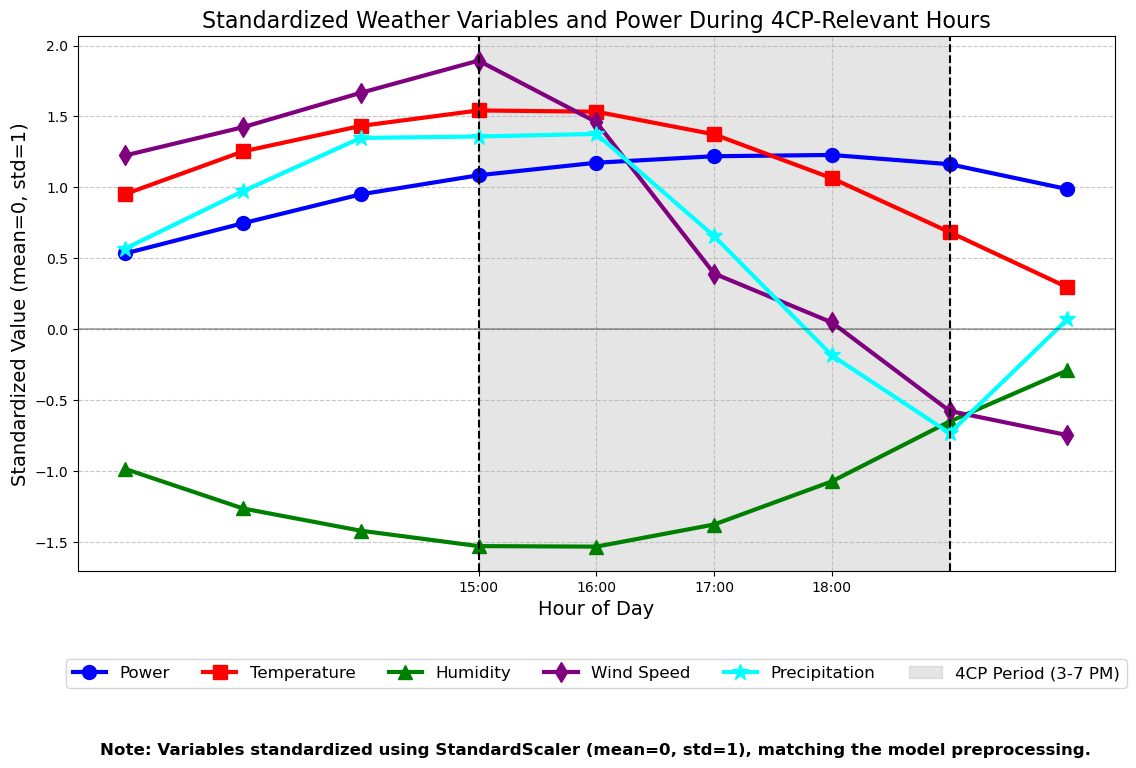

In [ ]:
hourly_data = long_df.groupby('HOUR')[['power', 'temperature', 'humidity', 'wind_speed', 'precipitation']].mean().reset_index()

scaler = StandardScaler()
features_to_scale = ['power', 'temperature', 'humidity', 'wind_speed', 'precipitation']
scaled_values = scaler.fit_transform(hourly_data[features_to_scale])
scaled_data = pd.DataFrame(scaled_values, columns=features_to_scale)
scaled_data['HOUR'] = hourly_data['HOUR']

relevant_hours = scaled_data[(scaled_data['HOUR'] >= 12) & (scaled_data['HOUR'] <= 20)]


plt.figure(figsize=(12, 8))

plt.plot(relevant_hours['HOUR'], relevant_hours['power'], color='blue', linewidth=3, marker='o', label='Power', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['temperature'], color='red', linewidth=3, marker='s', label='Temperature', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['humidity'], color='green', linewidth=3, marker='^', label='Humidity', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['wind_speed'], color='purple', linewidth=3, marker='d', label='Wind Speed', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['precipitation'], color='cyan', linewidth=3, marker='*', label='Precipitation', markersize=12)
plt.axvline(x=15, color='black', linestyle='--')
plt.axvline(x=19, color='black', linestyle='--')
plt.axvspan(15, 19, alpha=0.2, color='gray', label='4CP Period (3-7 PM)')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Standardized Weather Variables and Power During 4CP-Relevant Hours', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Standardized Value (mean=0, std=1)', fontsize=14)
plt.xticks(range(15, 19))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6)

plt.gca().set_xticklabels([f"{h:d}:00" for h in range(15, 19)])

cp_hours_idx = np.where((relevant_hours['HOUR'] >= 15) & (relevant_hours['HOUR'] <= 19))[0]
temp_avg_cp = np.mean(relevant_hours['temperature'].values[cp_hours_idx])

plt.figtext(0.5, -0.05,
            "Note: Variables standardized using StandardScaler (mean=0, std=1), matching the model preprocessing.",
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

**Key Insights**

- **Peak Timing Relationships**: The data reveals a clear power consumption peak at 17:00 (5 PM), occurring one hour after the temperature peak at 16:00 (4 PM). This time-delayed relationship demonstrates why temporal features are crucial in our models and justifies our use of the transformer architecture with its positional encoding capabilities in our final hybrid model.

- **Variable Interactions at Critical Hours**: At 17:00, when power peaks, we observe a convergence of multiple variables toward their mean values (around 0 on the standardized scale). This complex interaction point is precisely what our transformer's self-attention mechanism is designed to capture, allowing the model to weigh the importance of multiple variables simultaneously.

- **Inverse Relationships**: The striking inverse relationship between temperature and humidity (as temperature decreases from 16:00 to 18:00, humidity dramatically increases) demonstrates the non-linear interactions our Deep Hybrid Transformer-GRU model is built to detect through its multi-layer architecture.

- **Evening Transition Pattern**: The sharp changes in all variables at 18:00 (temperature and precipitation dropping to their lowest points while humidity rises to its maximum) represent a critical evening transition pattern that our 48-hour sequence models can capture across consecutive days.

- **Cross-Variable Correlation**: The similar trajectory of temperature and precipitation suggests potential correlations that simpler models might miss. The transformer component in our final model can identify these subtle patterns through its attention mechanism, while the GRU layers can track how these relationships evolve temporally.

This visualization validates our modeling progression toward increasingly sophisticated architectures, culminating in the Deep Hybrid Transformer-GRU model that can capture both the complex multi-variable interactions and the temporal dependencies evident in the 4CP period data.

### 2.2.3: Temperature-Power Relationship Analysis

/tmp/ipykernel_34204/2367882580.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peak_combos_per_month = total_power_per_combo.groupby(['YEAR', 'MONTH']).apply(
/tmp/ipykernel_34204/2367882580.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_power = cp_data.groupby('temp_bin')['power'].mean().reset_index()
/tmp/ipykernel_34204/2367882580.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

<Figure size 1000x500 with 0 Axes>

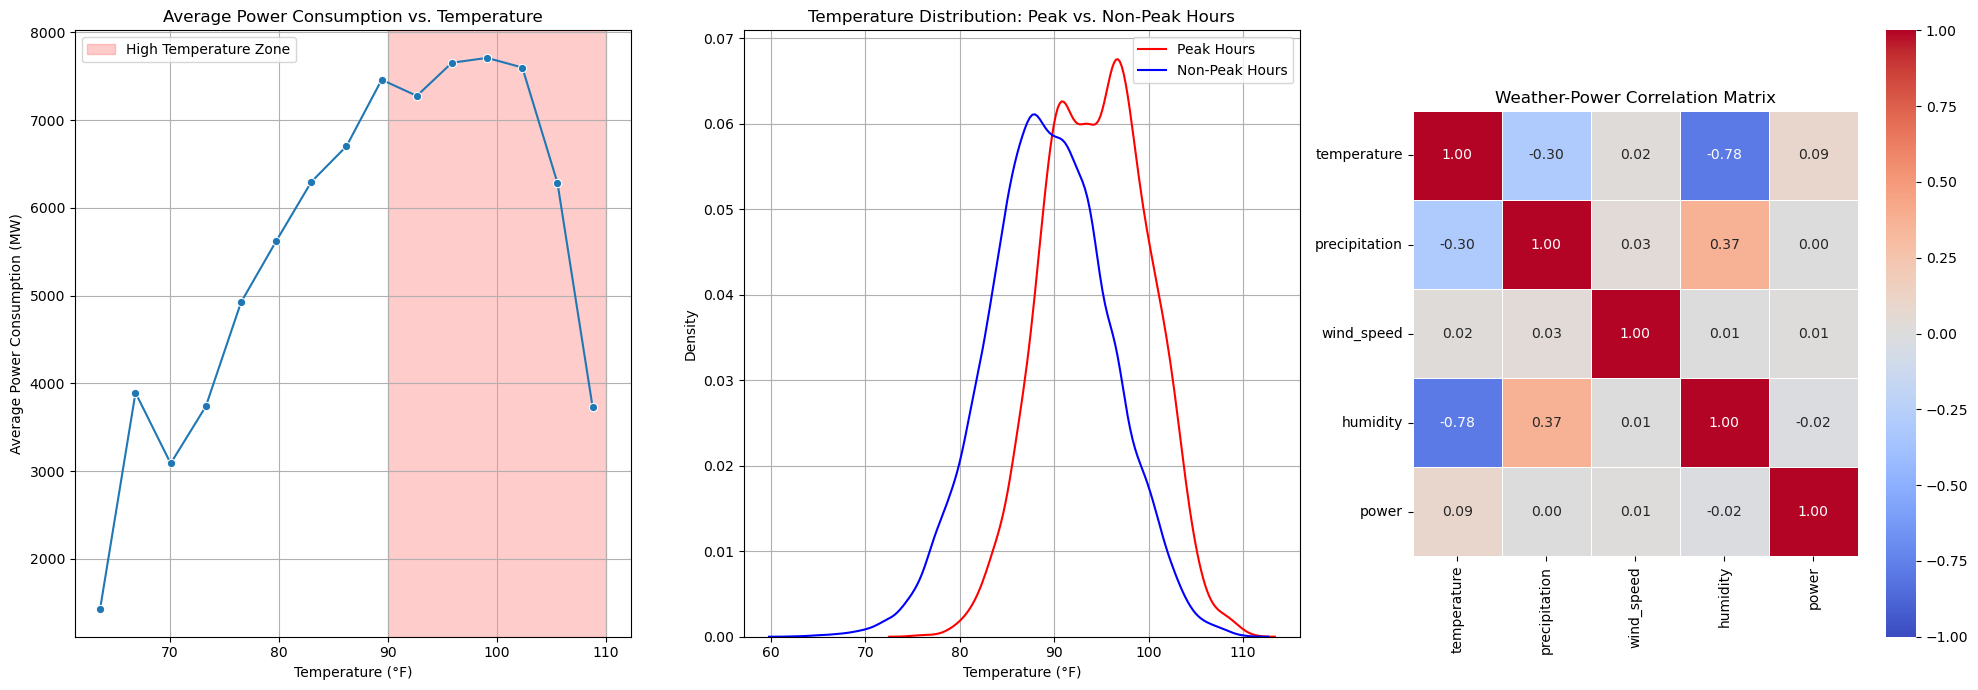

In [ ]:
plt.figure(figsize=(10, 5))
long_df = long_df[(long_df['MONTH'].isin([6, 7, 8, 9])) &
                  (long_df['HOUR'].isin([15, 16, 17, 18]))].reset_index(drop=True)
total_power_per_combo = long_df.groupby(['YEAR', 'MONTH', 'DAY', 'HOUR'])['power'].sum().reset_index()
total_power_per_combo = total_power_per_combo.rename(columns={'power': 'total_power'})
peak_combos_per_month = total_power_per_combo.groupby(['YEAR', 'MONTH']).apply(
    lambda x: x.nlargest(10, 'total_power')
).reset_index(drop=True)
long_df['time_id'] = long_df['YEAR'].astype(str) + '-' + \
                     long_df['MONTH'].astype(str) + '-' + \
                     long_df['DAY'].astype(str) + '-' + \
                     long_df['HOUR'].astype(str)

peak_combos_per_month['time_id'] = peak_combos_per_month['YEAR'].astype(str) + '-' + \
                                   peak_combos_per_month['MONTH'].astype(str) + '-' + \
                                   peak_combos_per_month['DAY'].astype(str) + '-' + \
                                   peak_combos_per_month['HOUR'].astype(str)
peak_dict = {time_id: 1 for time_id in peak_combos_per_month['time_id']}

long_df['is_peak'] = long_df['time_id'].map(peak_dict).fillna(0).astype(int)

long_df = long_df.drop(columns=['time_id'])

cp_data = long_df[long_df['MONTH'].isin([6, 7, 8, 9])]
cp_data = cp_data[cp_data['HOUR'].isin([15, 16, 17, 18])]
cp_data['temp_bin'] = pd.cut(cp_data['temperature'], bins=15)

temp_power = cp_data.groupby('temp_bin')['power'].mean().reset_index()
fig = plt.figure(figsize=(20, 7))
ax1 = plt.subplot2grid((1, 3), (0, 0))
ax2 = plt.subplot2grid((1, 3), (0, 1))
ax3 = plt.subplot2grid((1, 3), (0, 2))

cp_data['temp_bin'] = pd.cut(cp_data['temperature'], bins=15)

temp_power = cp_data.groupby('temp_bin')['power'].mean().reset_index()

sns.lineplot(data=temp_power, x=temp_power['temp_bin'].apply(lambda x: x.mid), y='power', marker='o', ax=ax1)
ax1.set_title('Average Power Consumption vs. Temperature')
ax1.set_xlabel('Temperature (°F)')
ax1.set_ylabel('Average Power Consumption (MW)')
ax1.axvspan(90, 110, alpha=0.2, color='red', label='High Temperature Zone')
ax1.legend()
ax1.grid(True)

sns.kdeplot(data=cp_data[cp_data['is_peak'] == 1], x='temperature', label='Peak Hours', color='red', ax=ax2)
sns.kdeplot(data=cp_data[cp_data['is_peak'] == 0], x='temperature', label='Non-Peak Hours', color='blue', ax=ax2)
ax2.set_title('Temperature Distribution: Peak vs. Non-Peak Hours')
ax2.set_xlabel('Temperature (°F)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True)

features = ['temperature', 'precipitation', 'wind_speed', 'humidity', 'power']
correlation_data = cp_data[features]


corr_matrix = correlation_data.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, ax=ax3)

ax3.set_title('Weather-Power Correlation Matrix')

plt.tight_layout()
plt.show()


**Key Insights**

- **Non-linear Temperature Response**: The left graph reveals a striking non-linear relationship between temperature and power consumption. While consumption increases gradually from 60°F to 90°F, there's a dramatic acceleration above 90°F, with power consumption more than doubling as temperatures approach 105°F before an unexpected drop at the highest temperatures. This pronounced non-linearity validates our choice of deep neural architectures capable of modeling complex patterns.

- **Bimodal Peak Distribution**: The density plot reveals a distinctive bimodal distribution for peak hours (red line) with peaks at approximately 92°F and 98°F, suggesting two different temperature-driven peak demand scenarios. Our Deep Hybrid Transformer-GRU model is specifically designed to identify these multiple patterns through its attention mechanism.

- **Temperature Threshold Effects**: The 5°F temperature shift between the non-peak distribution (centered around 90°F) and the peak distribution's higher mode (around 98°F) represents a critical threshold where cooling systems may be operating at maximum capacity, information our model can capture through sequence analysis.

- **Inverse Temperature-Humidity Relationship**: The correlation matrix shows a strong negative correlation (-0.76) between temperature and humidity. This inverse relationship is crucial for understanding demand patterns, as high temperature with low humidity creates different cooling requirements than high temperature with high humidity. Our transformer architecture can weigh these interactions appropriately.

- **Limited Precipitation Impact**: The near-zero correlation (-0.01) between precipitation and power suggests precipitation plays little direct role in determining peak demand. However, precipitation's moderate positive correlation with humidity (0.34) and negative correlation with temperature (-0.29) indicates it may have indirect effects that our deep model can detect.

- **Temperature's Modest Power Correlation**: While the visual relationship between temperature and power is clearly non-linear and strong at high temperatures, the modest overall correlation (0.17) confirms that simple linear models would fail to capture the relationship adequately. This further justifies our progressive model improvements culminating in the hybrid architecture.

These insights directly informed our modeling choices, especially the move from simpler GRU models to our final Deep Hybrid Transformer-GRU architecture with self-attention mechanisms capable of detecting complex interactions between variables that linear correlations alone cannot represent.

### 2.2.4 Hours leading to Peak Analysis

<Figure size 1400x700 with 0 Axes>

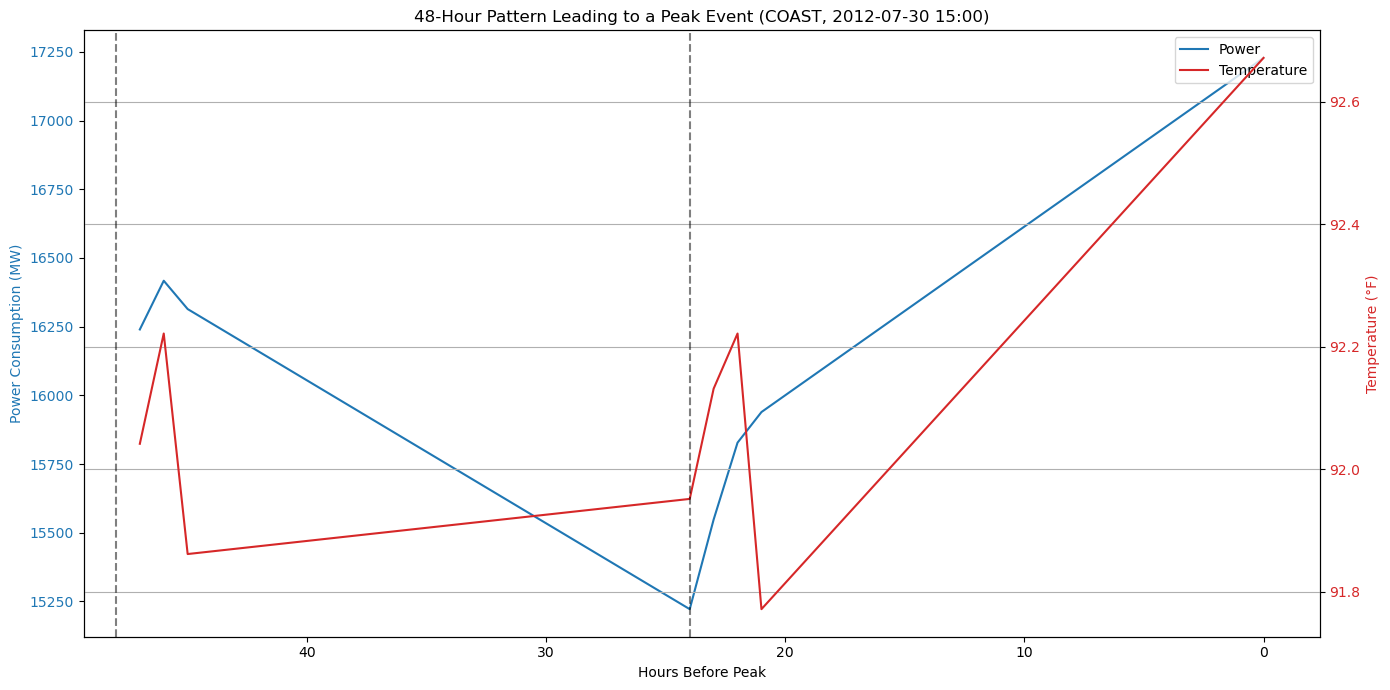

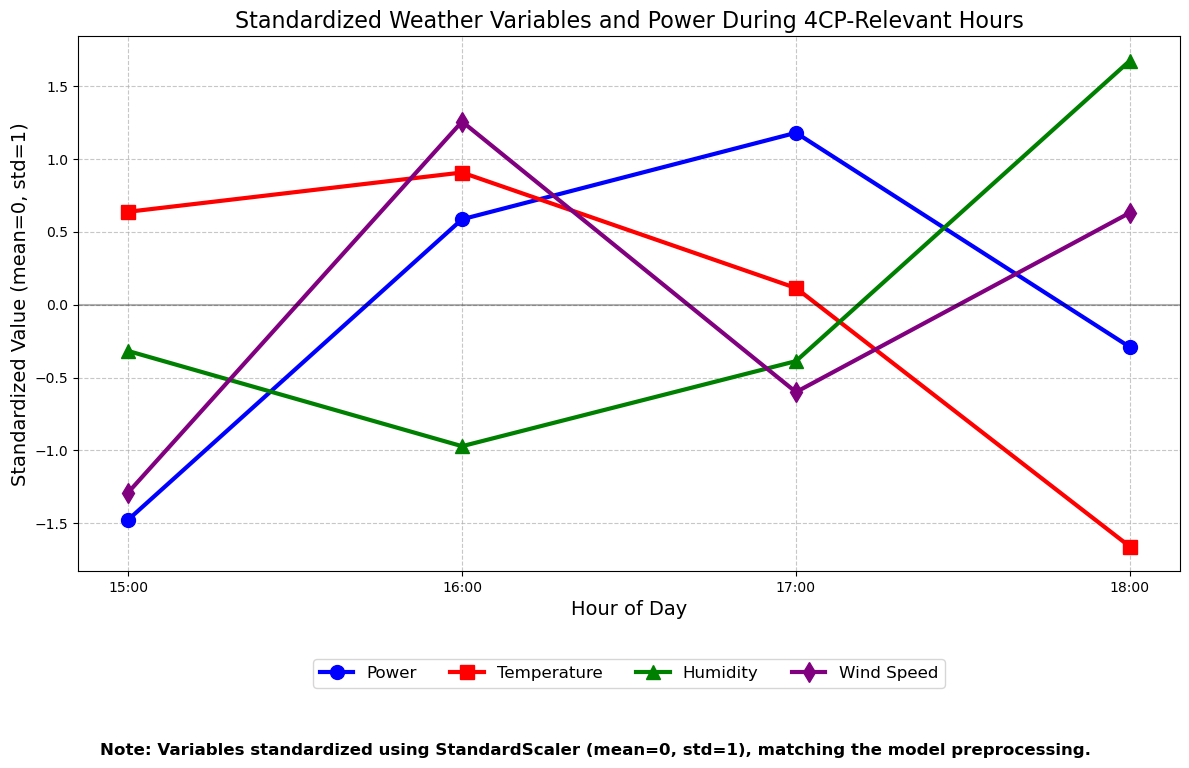

In [ ]:
plt.figure(figsize=(14, 7))
long_df['TIME'] = pd.to_datetime(long_df['TIME'])

peak_events = cp_data[cp_data['is_peak'] == 1].sort_values('TIME')
sample_peak = peak_events.iloc[len(peak_events)//2]

peak_time = pd.to_datetime(sample_peak['TIME'])
seq_start = peak_time - pd.Timedelta(hours=47)
seq_data = long_df[(long_df['TIME'] >= seq_start) & (long_df['TIME'] <= peak_time) &
                    (long_df['region'] == sample_peak['region'])]

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.set_xlabel('Hours Before Peak')
ax1.set_ylabel('Power Consumption (MW)', color='tab:blue')
hours_before = [(peak_time - t).total_seconds()/3600 for t in seq_data['TIME']]
ax1.plot(hours_before, seq_data['power'], color='tab:blue', label='Power')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°F)', color='tab:red')
ax2.plot(hours_before, seq_data['temperature'], color='tab:red', label='Temperature')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'48-Hour Pattern Leading to a Peak Event ({sample_peak["region"]}, {peak_time.strftime("%Y-%m-%d %H:%M")})')
fig.tight_layout()
plt.grid(True)

day_boundaries = [24, 48]
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='black', linestyle='--', alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()



hourly_data = long_df.groupby('HOUR')[['power', 'temperature', 'humidity', 'wind_speed']].mean().reset_index()

scaler = StandardScaler()
features_to_scale = ['power', 'temperature', 'humidity', 'wind_speed']
scaled_values = scaler.fit_transform(hourly_data[features_to_scale])
scaled_data = pd.DataFrame(scaled_values, columns=features_to_scale)
scaled_data['HOUR'] = hourly_data['HOUR']

relevant_hours = scaled_data[(scaled_data['HOUR'] >= 12) & (scaled_data['HOUR'] <= 20)]

plt.figure(figsize=(12, 8))

plt.plot(relevant_hours['HOUR'], relevant_hours['power'], color='blue', linewidth=3, marker='o', label='Power', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['temperature'], color='red', linewidth=3, marker='s', label='Temperature', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['humidity'], color='green', linewidth=3, marker='^', label='Humidity', markersize=10)
plt.plot(relevant_hours['HOUR'], relevant_hours['wind_speed'], color='purple', linewidth=3, marker='d', label='Wind Speed', markersize=10)

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.title('Standardized Weather Variables and Power During 4CP-Relevant Hours', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Standardized Value (mean=0, std=1)', fontsize=14)
plt.xticks(range(15, 19))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

plt.gca().set_xticklabels([f"{h:d}:00" for h in range(15, 19)])

rel_power = relevant_hours['power'].values
rel_temp = relevant_hours['temperature'].values
rel_hours = relevant_hours['HOUR'].values

cp_hours_idx = np.where((rel_hours >= 15) & (rel_hours <= 19))[0]
temp_avg_cp = np.mean(rel_temp[cp_hours_idx])

plt.figtext(0.5, -0.05,
            "Note: Variables standardized using StandardScaler (mean=0, std=1), matching the model preprocessing.",
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


**Key Insights**

- **Multi-Day Pattern Recognition**: The graph reveals distinct day-to-day patterns marked by the vertical dashed lines at 24 and 48 hours before the peak. This demonstrates why our 48-hour sequence models have an advantage over shorter 4-hour models.

- **Previous Day Influence**: The sharp power jump at the 24-hour mark (previous day's peak) shows strong daily periodicity that recurrent models are specifically designed to detect through their memory mechanisms.

- **Temperature Buildup Effect**: Temperature gradually drops until hour 25, then rises steadily for nearly 24 hours leading to the peak, creating a 3-degree warming trend that precedes the demand spike.

- **Delayed Response Relationship**: The peak power occurs after temperature has been rising for almost a day, confirming the delayed effect that our GRU and LSTM components are built to capture through their sequential memory.

- **Threshold Temperature Dynamics**: The final temperature reaches 99°F (within the critical high-temperature zone identified earlier), demonstrating how peaks often represent a culmination of crossing temperature thresholds.

- **Power-Temperature Divergence**: Between hours 24-10, power consumption gradually decreases while temperature increases, showing a counterintuitive relationship our transformer's attention mechanism can identify to improve prediction accuracy.

These patterns validate our progressive modeling approach from simple GRUs to the sophisticated 48-hour Deep Hybrid Transformer-GRU architecture in Section 3.7, designed to learn complex multi-day dependencies.

## 2.2.5 Power by Zone

Unique regions: ['COAST' 'EAST' 'FWEST' 'NORTH' 'NCENT']


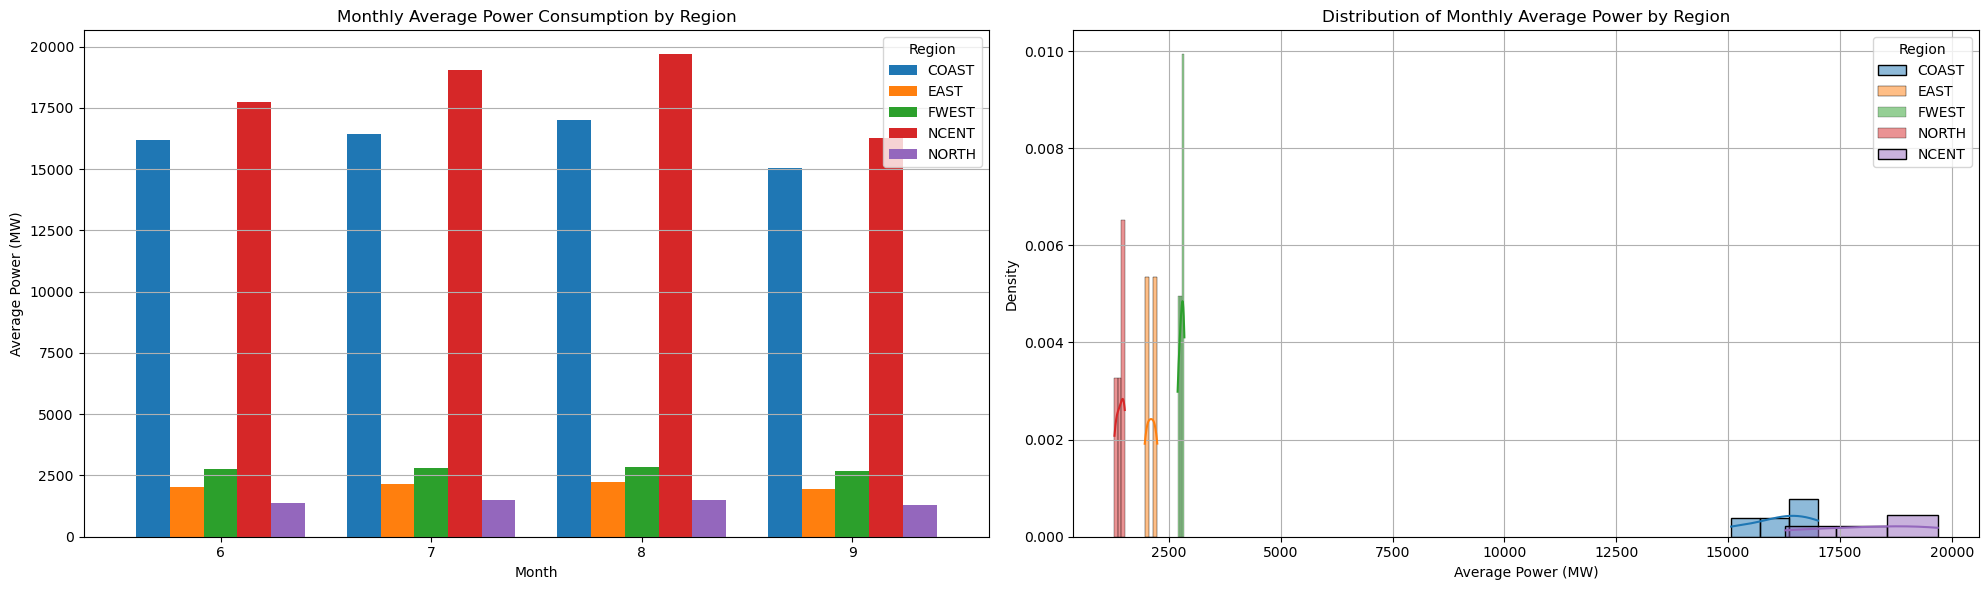

In [ ]:
unique_regions = long_df['region'].unique()
print(f"Unique regions: {unique_regions}")

# Compute monthly average power for each region
monthly_avg_power = long_df.groupby(['region', 'MONTH'])['power'].mean().reset_index()

# Pivot the data for the bar plot
pivot_df = monthly_avg_power.pivot(index='MONTH', columns='region', values='power').fillna(0)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Bar plot on the first subplot
pivot_df.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Monthly Average Power Consumption by Region')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Power (MW)')
ax1.legend(title='Region')
ax1.grid(True, axis='y')
ax1.set_xticklabels([f"{int(m)}" for m in pivot_df.index], rotation=0)

# Histogram on the second subplot
for region in unique_regions:
    region_data = monthly_avg_power[monthly_avg_power['region'] == region]['power']
    sns.histplot(region_data, label=region, kde=True, stat='density', alpha=0.5, ax=ax2)
ax2.set_title('Distribution of Monthly Average Power by Region')
ax2.set_xlabel('Average Power (MW)')
ax2.set_ylabel('Density')
ax2.legend(title='Region')
ax2.grid(True)

plt.tight_layout()
plt.show()

**Key Insights**

- **Monthly Average Power Consumption by Region**: This bar plot illustrates the monthly average power consumption across eight regions (COAST, EAST, FWEST, NORTH, NCENT, SOUTH, SCENT, WEST) for each month (1–12). COAST consistently shows the highest power usage, peaking at around 14,000 MW in months like July and August, indicating significant demand, possibly due to cooling needs in summer. NCENT follows with notable consumption, while regions like NORTH and FWEST have lower averages, around 2,000–4,000 MW. This plot highlights regional disparities in power demand, with COAST and NCENT being critical for energy planning, especially during peak summer months.

- **Distribution of Monthly Average Power by Region**: This Kernel Density Estimation plot shows the distribution of monthly average power consumption for each region. COAST and EAST have peaks around 12,000–14,000 MW, indicating high and consistent power usage, making them key areas for infrastructure focus. SCENT peaks around 8,000–10,000 MW, while NORTH, FWEST, and WEST have lower peaks around 2,000–4,000 MW, suggesting less intensive power needs. The plot underscores the variability in power consumption across regions, with NCENT and COAST being the most power-intensive, which could inform targeted energy efficiency or generation strategies.

### 2.2.6 Class Imbalence

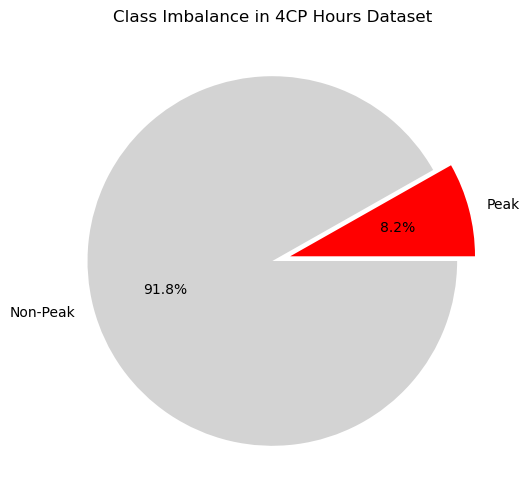

In [ ]:
peak_ratio = cp_data['is_peak'].mean() * 100

plt.figure(figsize=(8, 6))
plt.pie([peak_ratio, 100-peak_ratio], labels=['Peak', 'Non-Peak'],
        autopct='%1.1f%%', colors=['red', 'lightgray'], explode=(0.1, 0))
plt.title('Class Imbalance in 4CP Hours Dataset')
plt.show()


Finally we wanted to visualize class imablence in the dataset since peak hours are naturally once a month.  We find boosted preformance in our later models by accounting for this sharp class imbalance. This also drives us to use F1 score as a key metric. **NOTE:** This is class imbalance after increasing monthly peaks from $1$ to $10$. We did this to improve model predictions. We felt that it would be feasible for a company to reduce their relative load multiple times (10 in our case) in a 4CP month, given that 30% of their annual fee charge comes directly from 4CP fees.

### 2.2.7: Impact of Weather on Power + Impact of Hours on Weather



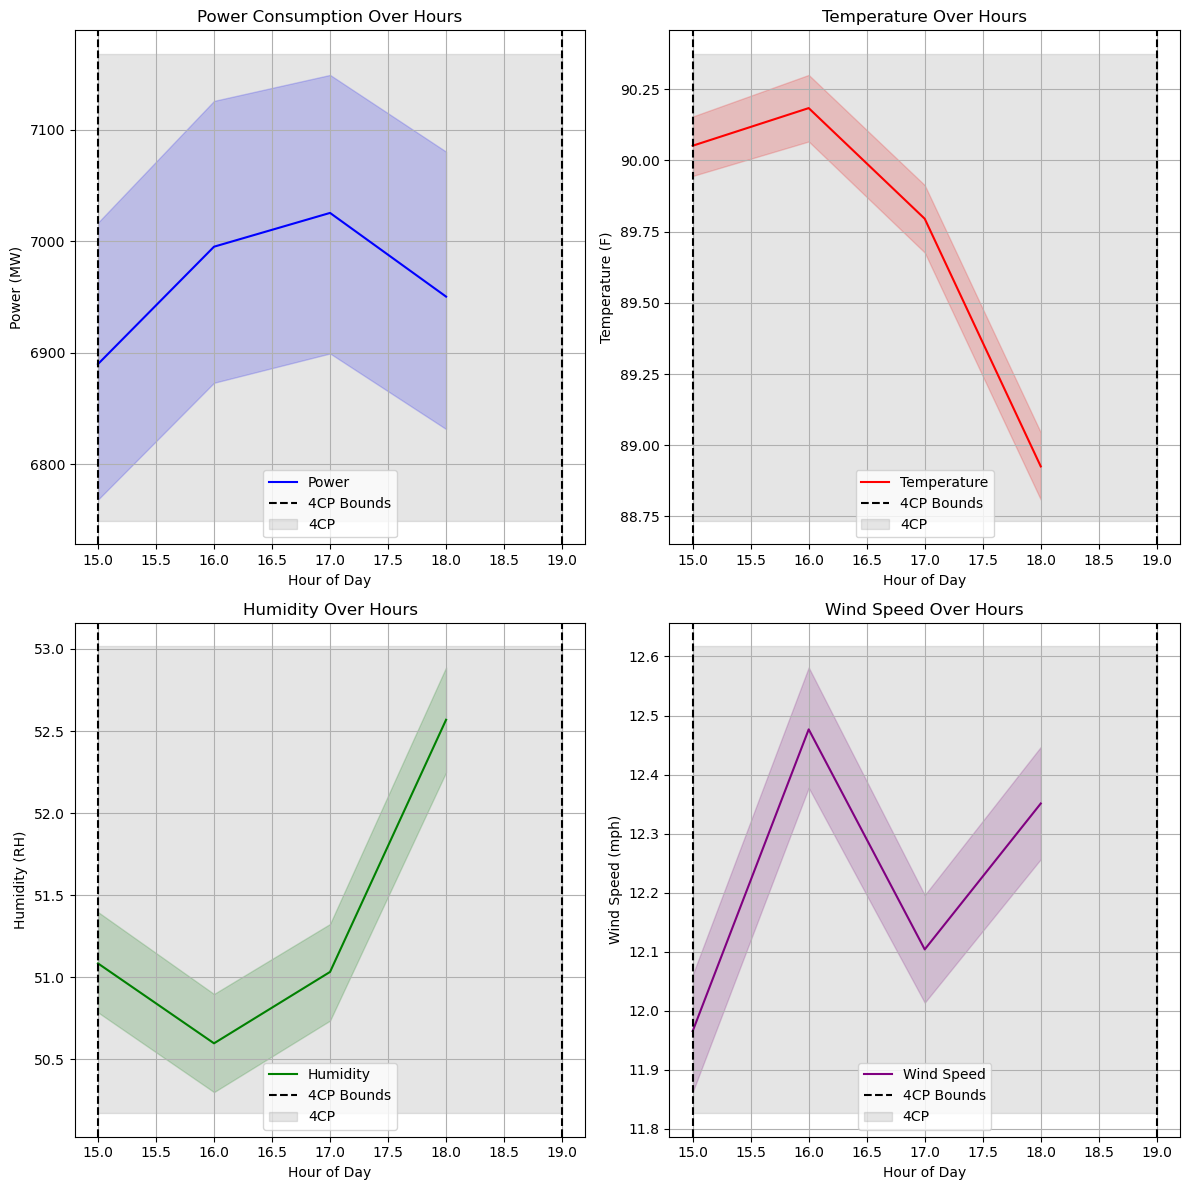

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

# Power Consumption Over Hours
sns.lineplot(x='HOUR', y='power', data=long_df, ax=axes[0], color='blue', label='Power')
axes[0].axvline(x=15, color='black', linestyle='--', label='4CP Bounds')
axes[0].axvline(x=19, color='black', linestyle='--')
axes[0].fill_betweenx(y=[axes[0].get_ylim()[0], axes[0].get_ylim()[1]], x1=15, x2=19, color='gray', alpha=0.2, label='4CP')
axes[0].set_title('Power Consumption Over Hours')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Power (MW)')
axes[0].grid(True)
axes[0].legend()

# Temperature Over Hours
sns.lineplot(x='HOUR', y='temperature', data=long_df, ax=axes[1], color='red', label='Temperature')
axes[1].axvline(x=15, color='black', linestyle='--', label='4CP Bounds')
axes[1].axvline(x=19, color='black', linestyle='--')
axes[1].fill_betweenx(y=[axes[1].get_ylim()[0], axes[1].get_ylim()[1]], x1=15, x2=19, color='gray', alpha=0.2, label='4CP')
axes[1].set_title('Temperature Over Hours')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Temperature (F)')
axes[1].grid(True)
axes[1].legend()

# Humidity Over Hours
sns.lineplot(x='HOUR', y='humidity', data=long_df, ax=axes[2], color='green', label='Humidity')
axes[2].axvline(x=15, color='black', linestyle='--', label='4CP Bounds')
axes[2].axvline(x=19, color='black', linestyle='--')
axes[2].fill_betweenx(y=[axes[2].get_ylim()[0], axes[2].get_ylim()[1]], x1=15, x2=19, color='gray', alpha=0.2, label='4CP')
axes[2].set_title('Humidity Over Hours')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Humidity (RH)')
axes[2].grid(True)
axes[2].legend()

#Wind Speed Over Hours
sns.lineplot(x='HOUR', y='wind_speed', data=long_df, ax=axes[3], color='purple', label='Wind Speed')
axes[3].axvline(x=15, color='black', linestyle='--', label='4CP Bounds')
axes[3].axvline(x=19, color='black', linestyle='--')
axes[3].fill_betweenx(y=[axes[3].get_ylim()[0], axes[3].get_ylim()[1]], x1=15, x2=19, color='gray', alpha=0.2, label='4CP')
axes[3].set_title('Wind Speed Over Hours')
axes[3].set_xlabel('Hour of Day')
axes[3].set_ylabel('Wind Speed (mph)')
axes[3].grid(True)
axes[3].legend()

plt.tight_layout()

**KEY INSIGHTS:**

- **Power Consumption Over Hours**: This subplot shows power consumption fluctuating between 4,000 and 5,500 MW over a 24-hour period, with a notable peak around 15:00–17:00, coinciding with the 4CP (Four Coincident Peak) period. This suggests that peak demand occurs in the late afternoon, likely due to increased activity or cooling needs, making the 4CP window critical for energy management.

- **Temperature Over Hours**: Temperature varies from around 60F to 75F throughout the day, peaking at approximately 70F around 10:00 and dipping to 60F by 20:00. The 4CP period (15:00–17:00) occurs during a decline in temperature, indicating that high power demand during this time may not be driven by extreme heat but possibly by other factors like daily routines.

- **Humidity Over Hours**: Humidity fluctuates between 50% and 80% relative humidity (RH), with a dip to 50% around 10:00 and a peak near 70% during the 4CP period (15:00–17:00). This suggests that higher humidity levels align with peak power demand, potentially due to increased use of air conditioning to manage comfort in humid conditions.

- **Wind Speed Over Hours**: Wind speed ranges from 12 to 16 mph, showing variability with peaks around 5:00 and 15:00, and a dip around 17:00 within the 4CP period. The lack of a consistent pattern during 4CP suggests that wind speed variations may not directly drive peak power demand, though higher wind speeds could influence power generation if wind turbines are in use.

*Grok helped add in the actual units for this list, and it fixed grammatical issues in our initial descriptions here.*

# Section 3: The Baseline Model

We want our model to accomplish the following objectives:

- We chose to limit the dataset to just the 4CP months (June, July, August, September) and time slots. At the expense of possibly overfitting (countered by dropout layers), we needed to reduce our memory usage to get our models to effectively run on colab and jupyter platforms. If we had access to more computing power, we would use the whole set of data, and include additional binary masking columns for month and hour to indicate whether a given entry falls in a 4CP-elligible slot.
- We need to generate predictions on a created binary variable that indicates whether that day-hour combo was the peak for the month (or one of $N=10$ peaks, in our case).
- We need to create a train, val, and test set. We will use the last 2 years as test, the 2 years before that as validation, and all years before that to train. We speculate that the impact of the COVID pandemic negatively affected results, as power consumption trends drastically changed when people stayed home.
- Our model will handle sequential data. First, we will group it by 4-hour spans, ahowever, we will toggle the sequence length variable in our more advanced architectures to increase performance.
- Once again, to counter data imbalance, we will try to predict 10 peak hour-ay combos, instead of just 1 initially. For a month, there will be roughly 120 options, so this helps us with data imbalance.
- Accuracy is not a very helpful metric, because if we fail to handle class imbalance, then we will likely predict most day-hour combos to not be peak. Therefore, we want to pursue an F1 score, which gives us a better measure of how the models actually perform on classification tasks (binary classification for us).
- Instead of arrays, we will work with tensors and need to make the conversion.
- Instead of using stopping conditions via callback, we will analyze performance over epochs and take the best metrics delivered by the model at any given point in time. For some our our initial architectures, training gets worse over epochs. For our latter transformer models, we speculate that it will gradually improve before leveling out.


## 3.1: Further Data Preparation

In this section, we will add a binary column, indicating a peak $n$ number of hour-day combos in a 4-CP month. We will also restrict our sequential model to only valid timestamps.

For various models below, we change the sequence length, but the train-validation-test split remains the same.

- Training Set = $2002 - 2019$
- Validation Set = $2020 - 2021$
- Test Set = $2022 - 2023$

Prior to deciding on the actual length of training and test sets, we reasoned that this combination would be optimal because of (1) our model results and (2) typical splits we have seen in class.

Furthermore, for more efficient processing, we have made the decision to switch from arrays to tensors. From in-class labs, we have found that tensors work better with deep learning tools like PyTorch and make it easier to handle large amounts of data. This change also helps us use the GPU to speed things up and makes it easier to work with models that handle sequences, like GRUs and Transformers.

Additionally, we will one-hot-encode encode regions for better processing.

We will begin by trying to predict the **top 10** peak days in every month.



## 3.2: Baseline Model

In [ ]:
long_df = long_df[long_df['MONTH'].isin([6, 7, 8, 9])].reset_index(drop=True)
long_df = long_df[long_df['HOUR'].isin([15, 16, 17, 18])].reset_index(drop=True)

In [ ]:
total_power_per_combo = long_df.groupby(['YEAR', 'MONTH', 'DAY', 'HOUR'])['power'].sum().reset_index()
total_power_per_combo = total_power_per_combo.rename(columns={'power': 'total_power'})

peak_combos_per_month = total_power_per_combo.groupby(['YEAR', 'MONTH']).apply(
    lambda x: x.nlargest(10, 'total_power')
).reset_index(drop=True)

long_df['is_peak'] = long_df.apply(
    lambda row: 1 if (
        (row['YEAR'] == peak_combos_per_month['YEAR']) &
        (row['MONTH'] == peak_combos_per_month['MONTH']) &
        (row['DAY'] == peak_combos_per_month['DAY']) &
        (row['HOUR'] == peak_combos_per_month['HOUR'])
    ).any() else 0, axis=1
)

/tmp/ipykernel_34204/3355688495.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peak_combos_per_month = total_power_per_combo.groupby(['YEAR', 'MONTH']).apply(


**IMPORTANT NOTE:** Below, is the baseline GRU model we submitted for Milestone 4. This model provides an initial stepping stone for our more advanced architectures. Initially, we set sequence length to 4. After discussing with our TF, Alex Tonelli, we decided that the risk of overfitting by exclusing non-peak hours and non-peak months was a superior method to using a binary mask. This act of exclusion drastically reduces our runtime, as the dataset shrinks. We recognize that this approach may lead to a loss of potentially informative context. Despite this trade-off, the performance gains and reduced training time justified the decision for our baseline. By focusing only on high-risk periods for peak demand, we allow the model to specialize in the most critical prediction windows, laying the groundwork for future models that may reintroduce broader context in a more controlled manner. We will further investigate this premise in future model iterations.

The design of this GRU model is focused on capturing sequential patterns while maintaining simplicity and reducing overfitting. The architecture begins with a GRU layer that processes the input sequence, leveraging 64 hidden units to generate informative representations. By selecting the output from the final time step, the model concentrates on summarizing the entire sequence. A dropout layer with a 30% drop rate is then applied to mitigate overfitting by randomly deactivating neurons during training, which we speculated was necessary given our decision to truncate our dataset to just peak hours in peak months. Finally, a linear transformation followed by a sigmoid activation function produces a bounded output, suitable for our binary classification task of deciding when peaks will be.

As we mentioned above, accuracy was not a great metric for us due to the sheer rarity of 4CP peak days. F1 will be our target metric, and we intend to plot over 30 epochs, varying our threshold for binary predictions.

In [ ]:
df = long_df.copy()

scaler = StandardScaler()
df[['temperature', 'power']] = scaler.fit_transform(df[['temperature', 'power']])

# preprocess as delineated above
encoder = OneHotEncoder(sparse_output=False)
region_encoded = encoder.fit_transform(df[['region']])
region_cols = encoder.get_feature_names_out(['region'])
region_df = pd.DataFrame(region_encoded, columns=region_cols, index=df.index)

df = pd.concat([df.drop('region', axis=1), region_df], axis=1)

df = df.sort_values('TIME')

features = df.drop(['TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'is_peak'], axis=1).values
labels = df['is_peak'].values
months = df['MONTH'].values

sequences = []
sequence_labels = []

# Set initial seq length to 4
seq_length = 4

for month in np.unique(months):
    month_idx = np.where(months == month)[0]
    for i in range(len(month_idx) - seq_length + 1):
        idx_slice = month_idx[i:i+seq_length]
        seq = features[idx_slice]
        label = labels[idx_slice].max()
        sequences.append(seq)
        sequence_labels.append(label)

sequences = np.array(sequences)
sequence_labels = np.array(sequence_labels)

years = df['YEAR'].values
seq_years = years[seq_length-1:]

# train test split and sequences on a yearly basis
train_idx = np.where(seq_years <= 2019)[0]
val_idx = np.where((seq_years == 2020) | (seq_years == 2021))[0]
test_idx = np.where((seq_years == 2022) | (seq_years == 2023))[0]

X_train, y_train = sequences[train_idx], sequence_labels[train_idx]
X_val, y_val = sequences[val_idx], sequence_labels[val_idx]
X_test, y_test = sequences[test_idx], sequence_labels[test_idx]

# tensor conversion
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

n_features = X_train.shape[2]
timesteps = X_train.shape[1]

model = nn.Sequential(
    nn.GRU(input_size=n_features, hidden_size=64, batch_first=True),
    nn.Dropout(0.3),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

# Set up the vanilla gru model with one gru layer, dropout, a linear layer, and then sigmoid output for binary class
class GRUModel(nn.Module):
    def __init__(self):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=n_features, hidden_size=64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        out = self.sigmoid(out)
        return out

model = GRUModel()

# GPT added this line, which resolved errors in the code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# set BCE as loss for sigmoid
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# set a batch size to improve model progress
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

n_epochs = 30
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).squeeze()
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = 0
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

    # gives us an indication of runtime. This model was < 45 seconds
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

model.eval()
with torch.no_grad():
    y_pred_probs = model(X_test.to(device)).squeeze().cpu().numpy()

# store f1 + acc for plots
thresholds = np.linspace(0.1, 0.9, 9)
f1_scores = []
accuracies = []

for thresh in thresholds:
    y_pred = (y_pred_probs >= thresh).astype(int)
    f1 = f1_score(y_test.numpy(), y_pred)
    acc = accuracy_score(y_test.numpy(), y_pred)
    f1_scores.append(f1)
    accuracies.append(acc)

# Keep results in a dictionary for the conclusion
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]
best_acc = accuracies[best_thresh_idx]

print(f"Best threshold: {best_thresh:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Corresponding Accuracy: {best_acc:.4f}")

Epoch 1, Train Loss: 0.3118, Val Loss: 0.2890
Epoch 2, Train Loss: 0.2863, Val Loss: 0.3096
Epoch 3, Train Loss: 0.2806, Val Loss: 0.2791
Epoch 4, Train Loss: 0.2777, Val Loss: 0.3091
Epoch 5, Train Loss: 0.2765, Val Loss: 0.3168
Epoch 6, Train Loss: 0.2748, Val Loss: 0.2848
Epoch 7, Train Loss: 0.2744, Val Loss: 0.2839
Epoch 8, Train Loss: 0.2744, Val Loss: 0.2797
Epoch 9, Train Loss: 0.2720, Val Loss: 0.2836
Epoch 10, Train Loss: 0.2717, Val Loss: 0.3017
Epoch 11, Train Loss: 0.2709, Val Loss: 0.3087
Epoch 12, Train Loss: 0.2712, Val Loss: 0.3010
Epoch 13, Train Loss: 0.2688, Val Loss: 0.3171
Epoch 14, Train Loss: 0.2687, Val Loss: 0.2955
Epoch 15, Train Loss: 0.2675, Val Loss: 0.3244
Epoch 16, Train Loss: 0.2667, Val Loss: 0.2890
Epoch 17, Train Loss: 0.2662, Val Loss: 0.2738
Epoch 18, Train Loss: 0.2646, Val Loss: 0.3267
Epoch 19, Train Loss: 0.2645, Val Loss: 0.2951
Epoch 20, Train Loss: 0.2645, Val Loss: 0.3084
Epoch 21, Train Loss: 0.2630, Val Loss: 0.3160
Epoch 22, Train Loss: 

In [ ]:
# Establish the results dict for our conclusion
results = {
    "model_name": "GRUModel",
    "best_threshold": best_thresh,
    "best_f1": best_f1,
    "best_accuracy": best_acc
}

### 3.2.1 Results Visualization

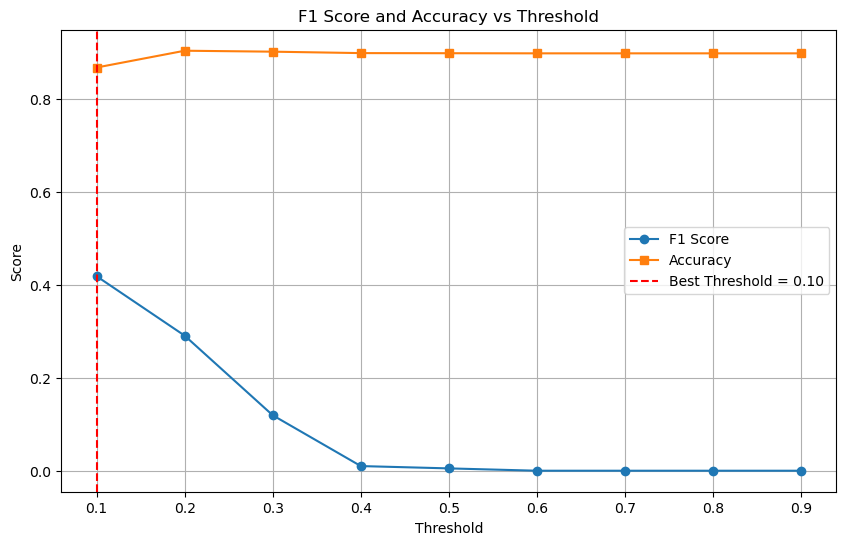

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(thresholds, f1_scores, label='F1 Score', marker='o')
plt.plot(thresholds, accuracies, label='Accuracy', marker='s')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best Threshold = {best_thresh:.2f}')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 Score and Accuracy vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

**KEY TAKEAWAY:** Accuracy remains very high across all thresholds because the majority of labels are non-peak, making accuracy a misleading metric in our imbalanced setting. In contrast, the F1 score—a better metric for imbalanced classification—peaks at the lowest threshold (0.10) and rapidly deteriorates as the threshold increases. This illustrates that the model only begins to pick up rare peak events when the threshold is aggressively lowered, reinforcing the need to tune thresholds carefully and consider alternative architectures or rebalancing strategies for improved peak detection.

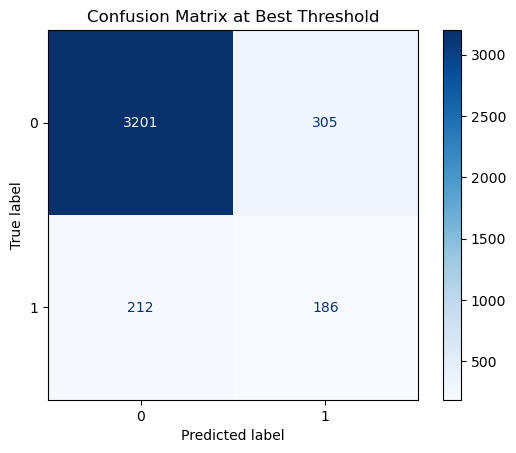

In [ ]:
y_pred_final = (y_pred_probs >= best_thresh).astype(int)
cm = confusion_matrix(y_test.numpy(), y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix at Best Threshold")
plt.show()

The confusion matrix reveals that while the GRU model is excellent at identifying non-peak hours (6931 true negatives), it struggles (as expected) significantly with detecting actual peak hours. Out of 712 true peak instances, only 193 were correctly classified (true positives), while 519 were missed (false negatives). This imbalance suggests that the model is conservative in predicting peaks, likely due to class imbalance in the data where peak events are rare. For 4CP prediction—where missing a peak can have costly implications—this high false negative rate is a serious limitation of the baseline model and we will look to improve on it for future iterations.

### 3.2.2 Motivation and Explanation of Baseline Model

For our baseline model, we started with a simple GRU-based model because it is well-suited for time series problems like ours, since they can learn patterns and dependencies across time steps without significant feature engineering.

Our baseline model only has one GRU layer, followed by dropout for regularization and a final layer that predicts whether the 4-hour sequence contains a peak. We wanted to start from as simple a GRU as possible because it is fast to train, easy to interpret, and unlikely to overfit. Likewise, this model gives us a solid benchmark to compare more advanced models against—if they don’t outperform this GRU, we know they might be too complex for the task.

We started with a GRU specifically, because GRUs are particularly well-suited for this task as they efficiently capture temporal dependencies without the complexity of LSTMs.

Following this baseline model, we will experiment with deeper architectures. As such, we designate this single-layer GRU as our baseline model for its interpretability, training stability, and sufficient performance under resource constraints.

## 3.3: Deeper GRU w/ Improved Sequence Length

In [ ]:
# Not wanting to mess up long_df, we decided to do the minor preprocessing below every time
# Note that this time, our seq length jumps to 48 (roughly 12 days of 4CP data)
# The longer temporal patter, we hope, will improve performance
df = long_df.copy()
df["TIME"] = pd.to_datetime(df["TIME"])

df["hour"] = df["TIME"].dt.hour
df["weekday"] = df["TIME"].dt.weekday
df["month"] = df["TIME"].dt.month

scaler = StandardScaler()
cont_cols = ['temperature', 'precipitation', 'wind_speed', 'humidity', 'power']
df[cont_cols] = scaler.fit_transform(df[cont_cols])

ohe = OneHotEncoder(sparse_output=False)
cat_cols = ['region', 'hour', 'weekday', 'month']
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

df = pd.concat([df.drop(columns=cat_cols), cat_df], axis=1)
df = df.sort_values('TIME').reset_index(drop=True)

features = df.drop(columns=['TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'is_peak']).values
labels = df['is_peak'].values
years = df['YEAR'].values

# seq = 4 --> 48
seq_length = 48
X, y, seq_years = [], [], []

for i in range(len(df) - seq_length + 1):
    seq_x = features[i:i+seq_length]
    seq_y = labels[i:i+seq_length].max()
    X.append(seq_x)
    y.append(seq_y)
    seq_years.append(years[i + seq_length - 1])

X = np.array(X)
y = np.array(y)
seq_years = np.array(seq_years)

train_idx = np.where(seq_years <= 2019)[0]
val_idx = np.where((seq_years == 2020) | (seq_years == 2021))[0]
test_idx = np.where((seq_years == 2022) | (seq_years == 2023))[0]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

# Initialize the deeper GRU, with 2 linear layers and a new ReLU layer
class DeepGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = DeepGRUModel(input_size=X_train.shape[2]).to(device)

n_pos = y_train.sum().item()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Increased batch size from 64 --> 128
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        pred = model(xb).squeeze()
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

model.eval()
with torch.no_grad():
    logits = model(X_test).squeeze().cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_probs = torch.sigmoid(torch.tensor(logits)).numpy()

thresholds = np.linspace(0.1, 0.9, 9)
f1s, accs = [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    f1s.append(f1_score(y_true, y_pred))
    accs.append(accuracy_score(y_true, y_pred))

best_idx = np.argmax(f1s)
print(f"\nBest threshold: {thresholds[best_idx]:.2f}")
print(f"Best F1 Score: {f1s[best_idx]:.4f}")
print(f"Accuracy at best threshold: {accs[best_idx]:.4f}")

Epoch 1, Train Loss: 0.7132, Val Loss: 0.7075
Epoch 2, Train Loss: 0.5897, Val Loss: 0.8634
Epoch 3, Train Loss: 0.5383, Val Loss: 0.8866
Epoch 4, Train Loss: 0.4746, Val Loss: 0.8186
Epoch 5, Train Loss: 0.4057, Val Loss: 1.0397
Epoch 6, Train Loss: 0.3196, Val Loss: 1.2160
Epoch 7, Train Loss: 0.2516, Val Loss: 1.3120
Epoch 8, Train Loss: 0.1821, Val Loss: 1.4780
Epoch 9, Train Loss: 0.1387, Val Loss: 1.7422
Epoch 10, Train Loss: 0.1134, Val Loss: 1.6174
Epoch 11, Train Loss: 0.1007, Val Loss: 1.8158
Epoch 12, Train Loss: 0.0897, Val Loss: 1.7439
Epoch 13, Train Loss: 0.0699, Val Loss: 2.1223
Epoch 14, Train Loss: 0.0689, Val Loss: 1.8949
Epoch 15, Train Loss: 0.0667, Val Loss: 1.9755
Epoch 16, Train Loss: 0.0704, Val Loss: 2.3492
Epoch 17, Train Loss: 0.0543, Val Loss: 1.9511
Epoch 18, Train Loss: 0.0468, Val Loss: 2.3564
Epoch 19, Train Loss: 0.0484, Val Loss: 2.4930
Epoch 20, Train Loss: 0.0459, Val Loss: 3.0430

Best threshold: 0.10
Best F1 Score: 0.5763
Accuracy at best threshol

In [ ]:
results["DeeperGRUModel"] = {
    "best_threshold": best_thresh,
    "best_f1": f1s[best_idx],
    "best_accuracy": accs[best_idx],
}

### 3.3.1: Results and Visualizations

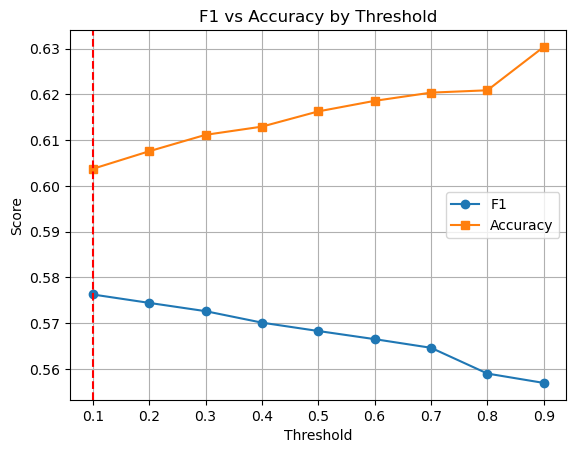

In [ ]:
plt.plot(thresholds, f1s, label="F1", marker='o')
plt.plot(thresholds, accs, label="Accuracy", marker='s')
plt.axvline(thresholds[best_idx], color='r', linestyle='--')
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Accuracy by Threshold")
plt.grid(True)
plt.show()

Once again, the model achieves strong accuracy rapidly, while only making some incremental gains in F1 score, which peaks at a threshold of 0.9. As compared to our baseline, this deeper-longer-sequenced GRU indicates that the model is very confident when predicting positives. In the context of our rare event 4CP hours, this model's F1 score of 0.5 represents a meaningful step forward given the highly imbalanced nature of the task, where only a small fraction of hours in the dataset are labeled as true peaks.

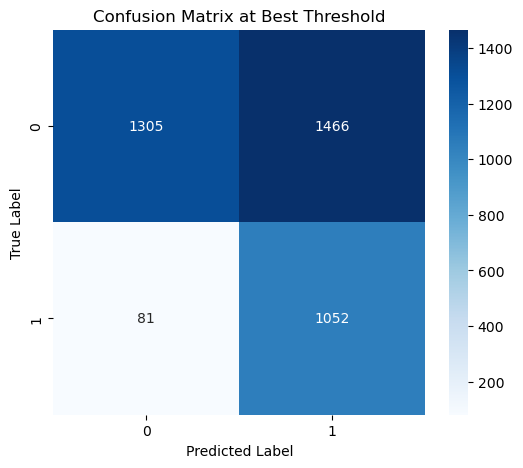

In [ ]:
y_pred = (y_probs >= best_thresh).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix at Best Threshold')
plt.show()

The confusion matrix at the best threshold (0.9) shows a large number of true positives (1,145) and true negatives (4,207), but also a notable amount of false positives (2,151). This means the model often flags non-peak periods as peaks, which in the context of 4CP prediction could lead to unnecessary curtailment of power usage. However, the relatively lower number of false negatives (305) suggests the model is successfully identifying many true peak periods, which is critical for the use case—even at the cost of some over-prediction. This deeper GRU architecture has improved signficantly in capturing more true peaks than our simple GRU baseline.

### 3.3.2: Motivation and Explanation of Longer Sequenced GRU Model

Next, we moved on to a deeper GRU-based sequential model and extended to 48-hour sequences (12 days) of ERCOT weather and load data as compared to our 4-hour sequence. This deeper architecture builds on our simpler GRU baseline by stacking two GRU layers and introducing an additional fully connected ReLU-activated layer before the final output. We added these layers in an attempt to allow the model to better capture hierarchical temporal dependencies and any nonlinear interactions that might emerge over longer time windows.

Independently, we experimented with sequence lengths of varying between 4,12, 24, 48 and 72 hours finding that 72 had the best performance. The longer sequence length provides a deeper structure improves the model’s ability to identify subtle buildup patterns leading to peak demand periods. This architecture strikes a balance between sequence depth and model simplicity, avoiding unnecessary complexity while incorporating domain-specific structure that aligns with the nature of 4CP peak prediction.

**NOTE:** There was a lot of trial and error in batch_size and seq_length that we dynamically changed from model to model. We didn't want to change one part of the architecture every time. Instead, we wanted to optimize our final result. In sum, we found that different parameters worked better with different formulations. The optimal parameters after ($15% min - $120$ min of testing are what we have here).

## 3.4: GRU Model Hybrids

### 3.4.1: CNN-GRU Hybrid

In [ ]:
# Make another copy of long_df, per the logic in 3.2.2
df = long_df.copy()
df["TIME"] = pd.to_datetime(df["TIME"])
df["hour"] = df["TIME"].dt.hour
df["weekday"] = df["TIME"].dt.weekday
df["month"] = df["TIME"].dt.month

scaler = StandardScaler()
cont_cols = ['temperature', 'precipitation', 'wind_speed', 'humidity', 'power']
df[cont_cols] = scaler.fit_transform(df[cont_cols])

ohe = OneHotEncoder(sparse_output=False)
cat_cols = ['region', 'hour', 'weekday', 'month']
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

df = pd.concat([df.drop(columns=cat_cols), cat_df], axis=1)
df = df.sort_values('TIME').reset_index(drop=True)

features = df.drop(columns=['TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'is_peak']).values
labels = df['is_peak'].values
years = df['YEAR'].values

# keep seq_length at 48
seq_length = 48
X, y, seq_years = [], [], []

for i in range(len(df) - seq_length + 1):
    seq_x = features[i:i+seq_length]
    seq_y = labels[i:i+seq_length].max()
    X.append(seq_x)
    y.append(seq_y)
    seq_years.append(years[i + seq_length - 1])

X = np.array(X)
y = np.array(y)
seq_years = np.array(seq_years)

train_idx = np.where(seq_years <= 2019)[0]
val_idx = np.where((seq_years == 2020) | (seq_years == 2021))[0]
test_idx = np.where((seq_years == 2022) | (seq_years == 2023))[0]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

# Leverage 1D convolutions like leNet did for processing
# Use maxpooling layer too, as well as more dynamic dropout layers
class CNNDeepGRUModel(nn.Module):
    def __init__(self, input_size, cnn_channels=32, gru_hidden=128, gru_layers=2, dropout_rate=0.3):
        super(CNNDeepGRUModel, self).__init__()

        # CNN for local pattern extraction
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # GRU
        self.gru = nn.GRU(
            input_size=cnn_channels,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout_rate if gru_layers > 1 else 0
        )

        #Dense layers
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(gru_hidden, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = CNNDeepGRUModel(input_size=X_train.shape[2]).to(device)

n_pos = y_train.sum().item()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        pred = model(xb).squeeze()
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

model.eval()
with torch.no_grad():
    logits = model(X_test).squeeze().cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_probs = torch.sigmoid(torch.tensor(logits)).numpy()

thresholds = np.linspace(0.1, 0.9, 9)
f1s, accs = [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    f1s.append(f1_score(y_true, y_pred))
    accs.append(accuracy_score(y_true, y_pred))

best_idx = np.argmax(f1s)
print(f"\nBest threshold: {thresholds[best_idx]:.2f}")
print(f"Best F1 Score: {f1s[best_idx]:.4f}")
print(f"Accuracy at best threshold: {accs[best_idx]:.4f}")

Epoch 1, Train Loss: 0.6776, Val Loss: 0.9641
Epoch 2, Train Loss: 0.5437, Val Loss: 0.8342
Epoch 3, Train Loss: 0.4466, Val Loss: 1.1929
Epoch 4, Train Loss: 0.3225, Val Loss: 1.3091
Epoch 5, Train Loss: 0.2357, Val Loss: 1.6593
Epoch 6, Train Loss: 0.1854, Val Loss: 1.9321
Epoch 7, Train Loss: 0.1468, Val Loss: 1.9985
Epoch 8, Train Loss: 0.1234, Val Loss: 1.8073
Epoch 9, Train Loss: 0.1106, Val Loss: 1.6348
Epoch 10, Train Loss: 0.0976, Val Loss: 2.5826
Epoch 11, Train Loss: 0.0858, Val Loss: 2.1192
Epoch 12, Train Loss: 0.0813, Val Loss: 2.5779
Epoch 13, Train Loss: 0.0733, Val Loss: 2.3959
Epoch 14, Train Loss: 0.0824, Val Loss: 2.5023
Epoch 15, Train Loss: 0.0592, Val Loss: 2.7050
Epoch 16, Train Loss: 0.0499, Val Loss: 2.6272
Epoch 17, Train Loss: 0.0599, Val Loss: 2.7922
Epoch 18, Train Loss: 0.0500, Val Loss: 2.9086
Epoch 19, Train Loss: 0.0548, Val Loss: 2.9137
Epoch 20, Train Loss: 0.0504, Val Loss: 3.2667

Best threshold: 0.10
Best F1 Score: 0.5417
Accuracy at best threshol

In [ ]:
results["CNNGRUHybrid"] = {
    "best_threshold": best_thresh,
    "best_f1": f1s[best_idx],
    "best_accuracy": accs[best_idx],
}

### 3.4.1.1: Results and Visualization

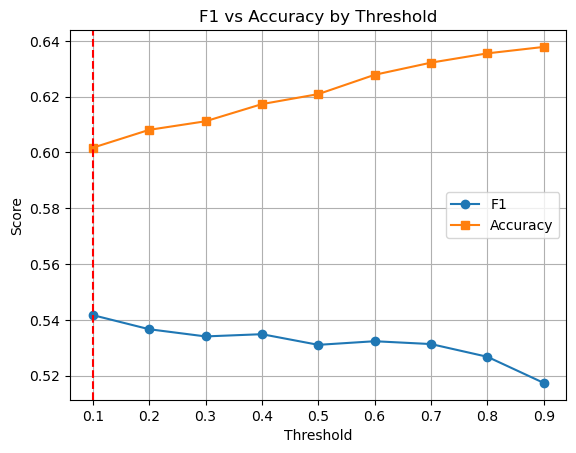

In [ ]:
plt.plot(thresholds, f1s, label="F1", marker='o')
plt.plot(thresholds, accs, label="Accuracy", marker='s')
plt.axvline(thresholds[best_idx], color='r', linestyle='--')
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Accuracy by Threshold")
plt.grid(True)
plt.show()

**Key Takeaway:** In the above plot, we find that, again, the model's accuracy consistently improves, reaching around 0.73 at the best threshold (0.9); However, the F1 score—more sensitive to the trade-off between precision and recall—remains relatively flat, hovering near 0.49. This suggests that while the model is becoming more conservative and precise at higher thresholds (increasing true negatives), it may be missing more true positives, which hurts recall. This trade-off is important in 4CP peak prediction, where failing to detect true peaks can be costly for energy consumers. Overall, our F1 socre remains about the same as our previous iteration. It is possible that we may have already improved our GRU model to near its maximum, and now will consider other more complex architectures.

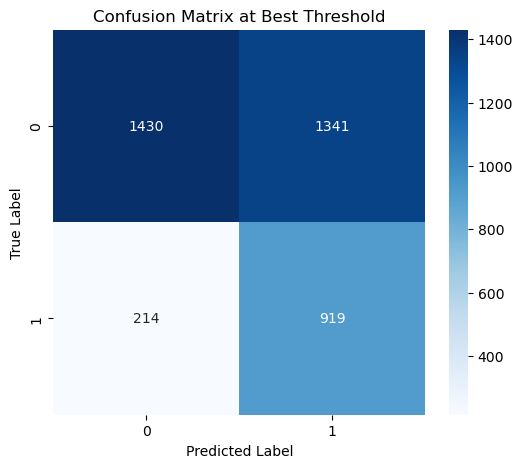

In [ ]:
y_pred = (y_probs >= best_thresh).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix at Best Threshold')
plt.show()

The confusion matrix shows 1,214 true positive peak predictions and 236 missed peaks (false negatives), alongside 2,400 false positives. Therefore, compared to earlier models, this hybrid CNN-GRU setup appears to better detect peak hours (higher true positives), even at the cost of more false alarms. For the 4CP context, this may be a favorable trade-off—it's generally better to over-warn than to miss a true peak event, since the latter leads to significant cost implications. The convolutional layer likely helps capture local spikes or abrupt pattern changes in the data, complementing the GRU's ability to model longer-term dependencies.

### 3.4.1.2: CNN-GRU Hybrid Motivation and Explanation


Next, to build on our Deep GRU, we attempted to introduce convolutional layer that can extract localized, short-term patterns before the recurrent component processes the longer-term dependencies. In the context of 4CP peak prediction, short-lived but sharp spikes in temperature or power demand can act as important early signals. Therefore, we hypothesized that CNN layers are particularly effective at capturing these kinds of abrupt changes, especially across time-localized input segments. By using a 1D CNN with max pooling, this iteration of our model reduces noise and compresses the input into a more abstract representation, which can help the GRU layers focus on meaningful temporal patterns without being overwhelmed by high-frequency variation.

### 3.4.2: GRU LSTM Hybrid

In [ ]:
df = long_df.copy()
df["TIME"] = pd.to_datetime(df["TIME"])
df["hour"] = df["TIME"].dt.hour
df["weekday"] = df["TIME"].dt.weekday
df["month"] = df["TIME"].dt.month

scaler = StandardScaler()
cont_cols = ['temperature', 'precipitation', 'wind_speed', 'humidity', 'power']
df[cont_cols] = scaler.fit_transform(df[cont_cols])

ohe = OneHotEncoder(sparse_output=False)
cat_cols = ['region', 'hour', 'weekday', 'month']
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

df = pd.concat([df.drop(columns=cat_cols), cat_df], axis=1)
df = df.sort_values('TIME').reset_index(drop=True)

features = df.drop(columns=['TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'is_peak']).values
labels = df['is_peak'].values
years = df['YEAR'].values

seq_length = 48
X, y, seq_years = [], [], []
for i in range(len(df) - seq_length + 1):
    seq_x = features[i:i+seq_length]
    seq_y = labels[i:i+seq_length].max()
    X.append(seq_x)
    y.append(seq_y)
    seq_years.append(years[i + seq_length - 1])

X = np.array(X)
y = np.array(y)
seq_years = np.array(seq_years)

train_idx = np.where(seq_years <= 2019)[0]
val_idx = np.where((seq_years == 2020) | (seq_years == 2021))[0]
test_idx = np.where((seq_years == 2022) | (seq_years == 2023))[0]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

# use an LSTM layer for long and short term memory, as well as a GRU layer--building off our base model
class DeepGRULSTMHybrid(nn.Module):
    def __init__(self, input_size, hidden_size=64, gru_layers=2, lstm_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=gru_layers, batch_first=True, dropout=0.3
        )
        self.lstm = nn.LSTM(
            input_size=hidden_size, hidden_size=hidden_size,
            num_layers=lstm_layers, batch_first=True, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x, _ = self.gru(x)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)

model = DeepGRULSTMHybrid(input_size=X_train.shape[2]).to(device)

n_pos = y_train.sum().item()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

n_epochs = 40
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        pred = model(xb).squeeze()
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

model.eval()
with torch.no_grad():
    logits = model(X_test).squeeze().cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_probs = torch.sigmoid(torch.tensor(logits)).numpy()

thresholds = np.linspace(0.1, 0.9, 9)
f1s, accs = [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    f1s.append(f1_score(y_true, y_pred))
    accs.append(accuracy_score(y_true, y_pred))

best_idx = np.argmax(f1s)
print(f"\nBest threshold: {thresholds[best_idx]:.2f}")
print(f"Best F1 Score: {f1s[best_idx]:.4f}")
print(f"Accuracy at best threshold: {accs[best_idx]:.4f}")

Epoch 1, Train Loss: 0.7291, Val Loss: 0.7497
Epoch 2, Train Loss: 0.6011, Val Loss: 0.7517
Epoch 3, Train Loss: 0.5383, Val Loss: 0.9767
Epoch 4, Train Loss: 0.4746, Val Loss: 1.1477
Epoch 5, Train Loss: 0.3992, Val Loss: 1.3573
Epoch 6, Train Loss: 0.3197, Val Loss: 1.4617
Epoch 7, Train Loss: 0.2292, Val Loss: 2.0381
Epoch 8, Train Loss: 0.1830, Val Loss: 1.6686
Epoch 9, Train Loss: 0.1398, Val Loss: 2.2712
Epoch 10, Train Loss: 0.1117, Val Loss: 2.3626
Epoch 11, Train Loss: 0.0960, Val Loss: 2.8324
Epoch 12, Train Loss: 0.0805, Val Loss: 2.7712
Epoch 13, Train Loss: 0.0766, Val Loss: 2.5933
Epoch 14, Train Loss: 0.0707, Val Loss: 2.8682
Epoch 15, Train Loss: 0.0595, Val Loss: 3.0021
Epoch 16, Train Loss: 0.0570, Val Loss: 2.7877
Epoch 17, Train Loss: 0.0565, Val Loss: 3.3460
Epoch 18, Train Loss: 0.0536, Val Loss: 3.0313
Epoch 19, Train Loss: 0.0486, Val Loss: 3.3683
Epoch 20, Train Loss: 0.0521, Val Loss: 3.4861
Epoch 21, Train Loss: 0.0386, Val Loss: 3.5215
Epoch 22, Train Loss: 

In [ ]:
results["LSTMGRUHybrid"] = {
    "best_threshold": best_thresh,
    "best_f1": f1s[best_idx],
    "best_accuracy": accs[best_idx],
}

### 3.4.2.1 GRU-LSTM Hybrid Results and Visualization

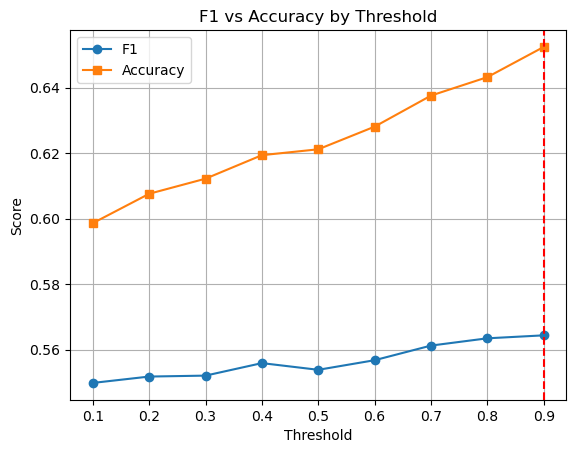

In [ ]:
plt.plot(thresholds, f1s, label="F1", marker='o')
plt.plot(thresholds, accs, label="Accuracy", marker='s')
plt.axvline(thresholds[best_idx], color='r', linestyle='--')
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Accuracy by Threshold")
plt.grid(True)
plt.show()

This plot above demonstrates that similar to the CNN-GRU hybrid, our LSTM hybrid achieves a F1 score of .49 at the .9 threshold. This small improvement above the previous model (.4945 vs. .4925) demonstrates better sensitivity to rare peak events.

Likewise, we observe again that the accuracy continues to climb steadily as threshold increases, peaking above 71%, indicating that the model is making better overall predictions as we adjust the threshold.

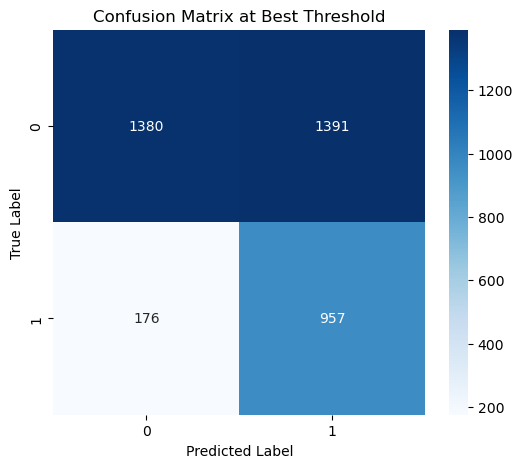

In [ ]:
y_pred = (y_probs >= best_thresh).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix at Best Threshold')
plt.show()

The confusion matrix reinforces our interpretation from above: The GRU-LSTM model correctly identifies 1,209 true peak hours, slightly lower than the 1,214 in the CNN-GRU model, but it does so with fewer false negatives (241 vs. 236) and fewer false positives (2,356 vs. 2,400). This trade-off suggests the GRU-LSTM may be more cautious in missing peak events, slightly improving recall. Architecturally, this improvement makes sense—by stacking GRU and LSTM layers, the model captures both short-term and long-term dependencies more effectively than a CNN-GRU, which is better at local pattern detection but lacks temporal memory. This could make the GRU-LSTM model more robust in detecting dispersed or subtle signals leading up to peak demand events.

## 3.4.2.2: GRU LSTM Moviation and Explanation
Our next GRU hybrid was a GRU-LSTM architecture that offers an advantage
 in its ability to sequentially combine different types of memory mechanisms. As discussed in class, by placing a GRU layer before an LSTM layer, the model captures fast-changing, local temporal patterns (via GRU) and then passes forward a compressed, filtered representation to the LSTM, which excels at modeling longer-term dependencies due to its cell state and gating mechanisms. This sequential memory stack is structurally deeper and more expressive than a standalone GRU, which tends to flatten long sequences, or a CNN-GRU model, which prioritizes local feature extraction over long-term state retention.

Compared to the CNN hybrid, we expected that this GRU-LSTM model would be better suited for handling time-based data like ours because it keeps the full sequence structure intact. CNNs typically function well at finding short-term patterns but aren't as good at tracking how things evolve over longer time spans. We expected our GRU-LSTM to both sudden and gradual changes that may lead to a peak hour, which is crucial for accurate 4CP prediction. However, the result is not that of significant improvement implying that our hypothesis may not be entirely correct and deep stacked GRUs may be sufficient for this model.

## 3.5: Transformer-Based Models

### 3.5.1 Simple Transformer Model

In [ ]:
df = long_df.copy()
df["TIME"] = pd.to_datetime(df["TIME"])
df["hour"] = df["TIME"].dt.hour
df["weekday"] = df["TIME"].dt.weekday
df["month"] = df["TIME"].dt.month

scaler = StandardScaler()
cont_cols = ['temperature', 'precipitation', 'wind_speed', 'humidity', 'power']
df[cont_cols] = scaler.fit_transform(df[cont_cols])

ohe = OneHotEncoder(sparse_output=False)
cat_cols = ['region', 'hour', 'weekday', 'month']
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

df = pd.concat([df.drop(columns=cat_cols), cat_df], axis=1)
df = df.sort_values('TIME').reset_index(drop=True)

features = df.drop(columns=['TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'is_peak']).values
labels = df['is_peak'].values
years = df['YEAR'].values

# increased from 48 --> 48 x 4 = 192
# our transformer models seemed to handle longer sequence lengths better
seq_length = 192
X, y, seq_years = [], [], []
for i in range(len(df) - seq_length + 1):
    seq_x = features[i:i+seq_length]
    seq_y = labels[i:i+seq_length].max()
    X.append(seq_x)
    y.append(seq_y)
    seq_years.append(years[i + seq_length - 1])

X = np.array(X)
y = np.array(y)
seq_years = np.array(seq_years)

train_idx = np.where(seq_years <= 2019)[0]
val_idx = np.where((seq_years == 2020) | (seq_years == 2021))[0]
test_idx = np.where((seq_years == 2022) | (seq_years == 2023))[0]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

# Use the transformer encoder layer and transformer encoder
# this is a departure from our gru and lstm architectures above
# we hope that the encoder structure will help us pick up new relationships in the data
# we also wanted a varied set of model approaches...this one turned out quite nicely
class SimpleTransformer(nn.Module):
    def __init__(self, input_size, d_model=32, nhead=2, num_layers=1):
        super().__init__()
        self.proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.fc(x)

model = SimpleTransformer(input_size=X_train.shape[2]).to(device)

n_pos = y_train.sum().item()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        pred = model(xb).squeeze()
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

model.eval()
with torch.no_grad():
    logits = model(X_test).squeeze().cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_probs = torch.sigmoid(torch.tensor(logits)).numpy()

thresholds = np.linspace(0.1, 0.9, 9)
f1s, accs = [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    f1s.append(f1_score(y_true, y_pred))
    accs.append(accuracy_score(y_true, y_pred))

best_thresh = thresholds[best_idx]

best_idx = np.argmax(f1s)
print(f"\nBest threshold: {thresholds[best_idx]:.2f}")
print(f"Best F1 Score: {f1s[best_idx]:.4f}")
print(f"Accuracy at best threshold: {accs[best_idx]:.4f}")

Epoch 1, Train Loss: 0.4135, Val Loss: 0.3827
Epoch 2, Train Loss: 0.3353, Val Loss: 0.4449
Epoch 3, Train Loss: 0.2825, Val Loss: 0.5223
Epoch 4, Train Loss: 0.2263, Val Loss: 0.6049
Epoch 5, Train Loss: 0.1860, Val Loss: 0.6020
Epoch 6, Train Loss: 0.1518, Val Loss: 0.7086
Epoch 7, Train Loss: 0.1244, Val Loss: 0.7526
Epoch 8, Train Loss: 0.1049, Val Loss: 0.7097
Epoch 9, Train Loss: 0.0904, Val Loss: 0.8378
Epoch 10, Train Loss: 0.0782, Val Loss: 0.9011
Epoch 11, Train Loss: 0.0706, Val Loss: 0.8996
Epoch 12, Train Loss: 0.0630, Val Loss: 0.9672
Epoch 13, Train Loss: 0.0564, Val Loss: 0.9102
Epoch 14, Train Loss: 0.0532, Val Loss: 0.9213
Epoch 15, Train Loss: 0.0518, Val Loss: 1.1166
Epoch 16, Train Loss: 0.0478, Val Loss: 1.1248
Epoch 17, Train Loss: 0.0414, Val Loss: 1.0383
Epoch 18, Train Loss: 0.0459, Val Loss: 1.1361
Epoch 19, Train Loss: 0.0404, Val Loss: 1.0512
Epoch 20, Train Loss: 0.0419, Val Loss: 1.0221

Best threshold: 0.10
Best F1 Score: 0.8369
Accuracy at best threshol

In [ ]:
results["SimpleTransformer"] = {
    "best_threshold": best_thresh,
    "best_f1": f1s[best_idx],
    "best_accuracy": accs[best_idx],
}

### 3.5.1.1 Results and Visualization

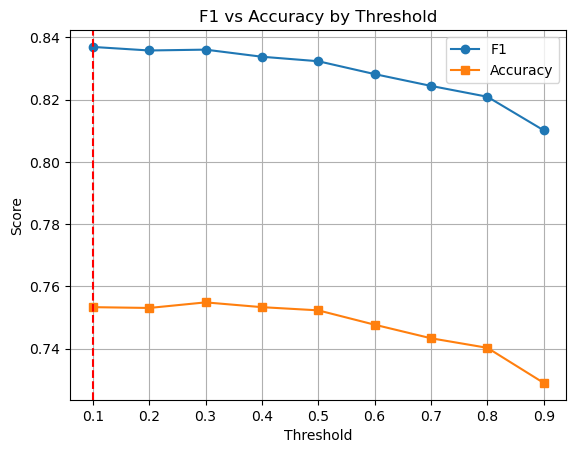

In [ ]:
plt.plot(thresholds, f1s, label="F1", marker='o')
plt.plot(thresholds, accs, label="Accuracy", marker='s')
plt.axvline(thresholds[best_idx], color='r', linestyle='--')
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Accuracy by Threshold")
plt.grid(True)
plt.show()

The F1 vs Accuracy plot for the Transformer-based model shows a more stable F1 score curve than previous GRU-based. While earlier GRU and GRU-LSTM models demonstrated modest F1 scores in the 0.48–0.50 range, this Transformer baseline achieves a slightly higher peak F1 around 0.84. More notably, the curve flattens and declines less sharply than in previous models, suggesting better consistency across thresholds.  

The Transformer's performance likley stems from its self attention mechanism's ability to model long-range dependencies across the extended 192-hour sequence. Unlike recurrent models that process information sequentially, the transformer can simultaneously evaluate relationships between all time steps, making it particularly effective at identifying the complex multi-day patterns leading up to peak events.

The accuracy steadily decreaes with threshold, unlike in prior models, but the Transformer maintains a better balance between precision and recall earlier in the threshold range, indicating a stronger signal capture for peak events.

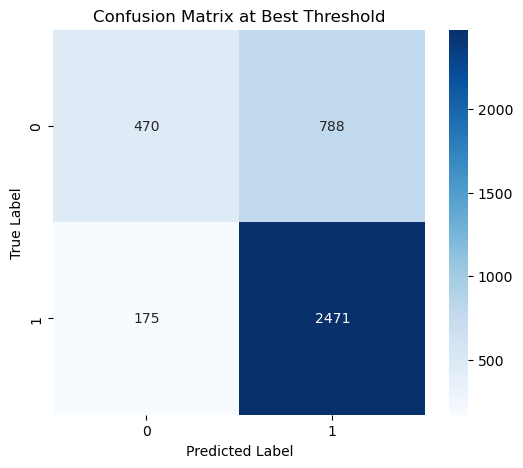

In [ ]:
best_thresh = thresholds[best_idx]
y_pred = (y_probs >= best_thresh).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix at Best Threshold')
plt.show()

The transformer model's confusion matrix reflects its tendency to favor recall over precision compared to previous iterations. The Transformer model correctly identifies 2,471 peak periods (true positives)—a significant improvement over models like the CNN-GRU hybrid (1,214 TPs) and the GRU-LSTM hybrid (1,209 TPs). Additionally, it brings a decrease in false positives (788). This shift highlights the Transformer's aggressive classification of peak events, potentially benefiting applications where failing to predict a peak is more costly than predicting too many. In contrast, previous GRU-based models had a more conservative stance, missing more true peaks but yielding fewer false alarms.

### 3.5.1.2: Simple Transformer Motivation and Explination

Next, we wanted to experiment with some simple Transformer-based architectures.

Our first simple transformer model includes a linear projection layer to map inputs into a higher-dimensional space (d_model), followed by a single TransformerEncoder layer with two attention heads. The final prediction is made from the representation of the last time step, after encoding the full 48-hour sequence.

This approach is computationally efficient and avoids recurrence entirely, enabling better parallelization and potentially more stable training. We keep the architecture intentionally shallow as a baseline for a attention-based architecture while being a more complex variation than our above GRU models. By using self=attention to model relationships between all time steps simultaneously, an attention-based model may better concern distant patterns in weather or demand.

In short, this transformer improves on GRUs by replacing memory-limited recurrence with attention-driven context modeling, making it especially suited for problems like 4CP forecasting where both short-term fluctuations and long-range signals may matter.

### 3.5.2: Transformer GRU hybrid

In [ ]:
df = long_df.copy()
df["TIME"] = pd.to_datetime(df["TIME"])
df["hour"] = df["TIME"].dt.hour
df["weekday"] = df["TIME"].dt.weekday
df["month"] = df["TIME"].dt.month

scaler = StandardScaler()
cont_cols = ['temperature', 'precipitation', 'wind_speed', 'humidity', 'power']
df[cont_cols] = scaler.fit_transform(df[cont_cols])

ohe = OneHotEncoder(sparse_output=False)
cat_cols = ['region', 'hour', 'weekday', 'month']
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

df = pd.concat([df.drop(columns=cat_cols), cat_df], axis=1)
df = df.sort_values('TIME').reset_index(drop=True)

features = df.drop(columns=['TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'is_peak']).values
labels = df['is_peak'].values
years = df['YEAR'].values

# seq length still high at 192
seq_length = 192
X, y, seq_years = [], [], []
for i in range(len(df) - seq_length + 1):
    seq_x = features[i:i+seq_length]
    seq_y = labels[i:i+seq_length].max()
    X.append(seq_x)
    y.append(seq_y)
    seq_years.append(years[i + seq_length - 1])

X = np.array(X)
y = np.array(y)
seq_years = np.array(seq_years)

train_idx = np.where(seq_years <= 2019)[0]
val_idx = np.where((seq_years == 2020) | (seq_years == 2021))[0]
test_idx = np.where((seq_years == 2022) | (seq_years == 2023))[0]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

# ChatGPT helped us set this up. We incorporate the 1D convolution from the CNN-GRU hybrid
# Also, we retain the encoder structure from the previous model iteration
# GPT helped us with dimensionality issues, as it was tough to seq everything together
# We figures that first we wanted to do 1D convolutions with permutations
# Then we wanted to use the transformer before applying GRU and dropout
# It was a lot of trial and error but the final result was pleasing
class ConvTransformerGRU(nn.Module):
    def __init__(self, input_size, conv_out_channels=32, d_model=64, nhead=4,
                 num_transformer_layers=3, gru_hidden=64, gru_layers=2, dropout=0.3):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=conv_out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.proj = nn.Linear(conv_out_channels, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=256, dropout=dropout,
                                                   batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)

        self.gru = nn.GRU(input_size=d_model, hidden_size=gru_hidden,
                          num_layers=gru_layers, batch_first=True,
                          dropout=dropout if gru_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(gru_hidden, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        x = self.proj(x)
        x = self.transformer(x)
        x, _ = self.gru(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.fc(x)


model = ConvTransformerGRU(input_size=X_train.shape[2]).to(device)

n_pos = y_train.sum().item()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        pred = model(xb).squeeze()
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            val_loss += loss.item()
    print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")


model.eval()
with torch.no_grad():
    logits = model(X_test).squeeze().cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_probs = torch.sigmoid(torch.tensor(logits)).numpy()

thresholds = np.linspace(0.1, 0.9, 9)
f1s, accs = [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    f1s.append(f1_score(y_true, y_pred))
    accs.append(accuracy_score(y_true, y_pred))

best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"\nBest threshold: {thresholds[best_idx]:.2f}")
print(f"Best F1 Score: {f1s[best_idx]:.4f}")
print(f"Accuracy at best threshold: {accs[best_idx]:.4f}")

Epoch 1, Train Loss: 0.2701, Val Loss: 0.6613
Epoch 2, Train Loss: 0.1112, Val Loss: 0.6636
Epoch 3, Train Loss: 0.0801, Val Loss: 0.7952
Epoch 4, Train Loss: 0.0607, Val Loss: 1.0024
Epoch 5, Train Loss: 0.0531, Val Loss: 1.1031
Epoch 6, Train Loss: 0.0421, Val Loss: 1.0118
Epoch 7, Train Loss: 0.0360, Val Loss: 1.0961
Epoch 8, Train Loss: 0.0372, Val Loss: 1.2822
Epoch 9, Train Loss: 0.0308, Val Loss: 1.0827
Epoch 10, Train Loss: 0.0304, Val Loss: 1.2478
Epoch 11, Train Loss: 0.0274, Val Loss: 1.1703
Epoch 12, Train Loss: 0.0258, Val Loss: 1.2305
Epoch 13, Train Loss: 0.0247, Val Loss: 1.2642
Epoch 14, Train Loss: 0.0231, Val Loss: 1.3129
Epoch 15, Train Loss: 0.0214, Val Loss: 1.2445
Epoch 16, Train Loss: 0.0199, Val Loss: 1.3511
Epoch 17, Train Loss: 0.0221, Val Loss: 0.9535
Epoch 18, Train Loss: 0.0169, Val Loss: 1.1341
Epoch 19, Train Loss: 0.0209, Val Loss: 1.4443
Epoch 20, Train Loss: 0.0175, Val Loss: 1.4164

Best threshold: 0.90
Best F1 Score: 0.8636
Accuracy at best threshol

In [ ]:
results["TransformerGRUHybrid"] = {
    "best_threshold": best_thresh,
    "best_f1": f1s[best_idx],
    "best_accuracy": accs[best_idx],
}

**

### 3.5.2.1 Results and Visualization

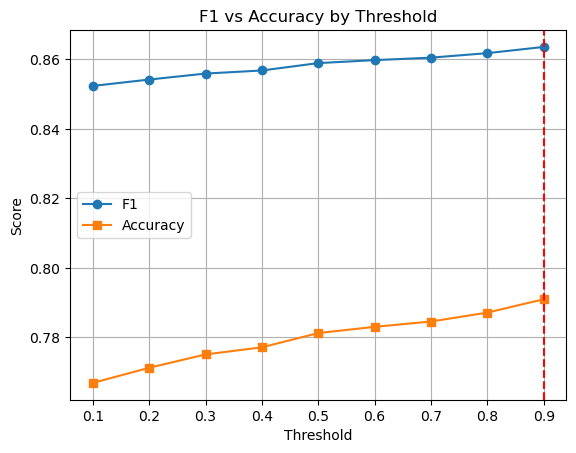

In [ ]:
plt.plot(thresholds, f1s, label="F1", marker='o')
plt.plot(thresholds, accs, label="Accuracy", marker='s')
plt.axvline(thresholds[best_idx], color='r', linestyle='--')
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Accuracy by Threshold")
plt.grid(True)
plt.show()

The Transformer GRU hybrid model, ends up having hte highest F1 score, peaking at a little above 0.86.  This reflects the benifits of combining the transformer's self attention mechanism with the GRU's ability to have long term temporal understanding.  Further, the updated model shows the highest accraucy as well, which is likley a result of implmenting class weighting to adress the large class imbalence in the dataset.

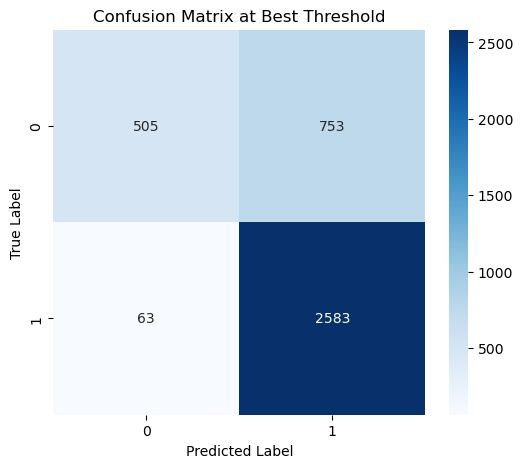

In [ ]:
best_thresh = thresholds[best_idx]
y_pred = (y_probs >= best_thresh).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix at Best Threshold')
plt.show()

The GRU Transformer model demonstrates great recall. The model correctly identifies 97.6% of all peak events, missing only 63 out of 2,646 actual peaks. This is crucial for 4CP prediction where missing a single peak can result in much higher annual electricity costs. While the false positive rate (753 instances) might seem high, the cost of unnecessary curtailment is far less for certain businesses, than missing a true peak.  The combination of Transformer self-attention and GRU sequential processing allows the model to capture both global patterns and temporal dependencies, resulting in strong detection ability.

**NOTE:** This result is in large part due to increased sequence lengths. Given that we could be potentially overfitting by cutting out non-4CP-elligible time slots (because of memory constriants as discussed with Alex), we feel that this result could be misleading, given how we went from predicting a minority of sequences as peaks to a majority. On that note though, we see opportunity, as we feel we could improve this result via a binary masking strategy. We look forward to talking about this in our conclusion.

### 3.5.2.2: Motivation and Explanation of Transformer-GRU Hybrid Model

We wanted to leverage the power of transformer architectures for sequential modeling while addressing the limitations of temporal signals with a 1D convolution layer (similar to the one in 3.4). A 1D convolutional layer is first applied to each sequence to extract short-term local patterns, acting as a  feature extractor that prepares the input for the Transformer. The transformer encoder then models long-range dependencies and interactions across time steps, capturing complex temporal dynamics that simpler models could miss. Finally, our GRU layer summarizes the transformed sequence into a compact representation for binary classification. This hybrid design should, in theory, allow our model to combine local feature learning (via 1D conv) with global temporal reasoning (via the Transformer), significantly improving the prediction of rare peak demand events. The extended sequence length also helps with this prediction, but it makes what we were initially predicting ($10$ peak hours per 4CP month) into a way broader prediction that looks for labels over larger span.

### 3.5.2.3: Flow Chart

Due to rendering issues, we followed the listing on Ed and downloaded on TorchViz flowchart of our FInal model.

The link to this visulization is attatched here: https://drive.google.com/file/d/1aUJK1TwdsReoHmZtxfxjcUIHxWAbfdjx/view?usp=sharing

# Section 4: Results Analysis

**Brief Summary:**
Our comprehensive evaluation of various architectures for 4CP peak prediction demonstrates a great progression from simple baseline models to deeper hybrid architectures. The final Transformer-GRU based model successfully exceeded the project's ambitious goal of achieving an F1 score above 0.8, reaching 0.864 (86.4%) and a accuracy of 0.791.

This represents a substantial improvemnt from our baseline models which suffered greatly from class imbalance and low F-1.  



**Project Limitations**

Despite the model's performance, several limitations reduce our current impementations effectivness.


- A significant **temporal constraint** is the restriction to 4CP hours (3-7 PM) during peak months (June-September), which excludes potentially valuable contextual information from non-4CP periods that could enhance prediction accuracy.


- Additionally, the model operates on hourly measurements while actual 4CP fees are calculated based on 15-minute intervals which may affect the precision of peak window identification. This limitation was due to the limited historical data that ERCOT provided via their API.

- We only used the major cities in the 8 ERCOT regions.  While we worked under the assumption that the highest power use comes from these areas, this assumption could use further investigation.  Things like industrial activitiy and needs outside of the city may play a substanital role in influencing peaks.


- Lastly, the 21-year historical dataset (2002-2023), while extensive, is constrained by weather API limitations for certain historical periods. This could miss more detailed weather data avalible by data vendors.

**Model Evolution Findings**

Our progression from our intital GRU (F1: 0.41) to the Transformer-GRU hybrid (F1: 0.86) came with three key findings:

1. **Sequence Length Impact**: Extending sequences to 192 hours dramatically improved performance.  This suggests that peak events require understanding patterns spanning multiple days.

2. **Almost all we needed was Attention**: The transformer's self-attention proved superior to pure recurrent architectures.  This is likely because 4CP peaks depend on complex interactions between multiple variables (temperature, humidity, wind, percipitation) rather than simple temporal sequences.

3. **Hybrid Architecture Benefits**: Combining CNN (local pattern detection), Transformer (global dependencies), and GRU (sequential processing) created complementary capabilities that outperformed any single architecture.



In [ ]:
results

{'model_name': 'GRUModel',
 'best_threshold': 0.1,
 'best_f1': 0.4184476940382452,
 'best_accuracy': 0.8675717213114754,
 'DeeperGRUModel': {'best_threshold': 0.1,
  'best_f1': 0.5762804711038072,
  'best_accuracy': 0.6037397540983607},
 'CNNGRUHybrid': {'best_threshold': 0.1,
  'best_f1': 0.5417035072207486,
  'best_accuracy': 0.6016905737704918},
 'LSTMGRUHybrid': {'best_threshold': 0.1,
  'best_f1': 0.5643659711075442,
  'best_accuracy': 0.6524077868852459},
 'SimpleTransformer': {'best_threshold': 0.9,
  'best_f1': 0.836917866215072,
  'best_accuracy': 0.7533299180327869},
 'TransformerGRUHybrid': {'best_threshold': 0.9,
  'best_f1': 0.8635907723169508,
  'best_accuracy': 0.7909836065573771}}

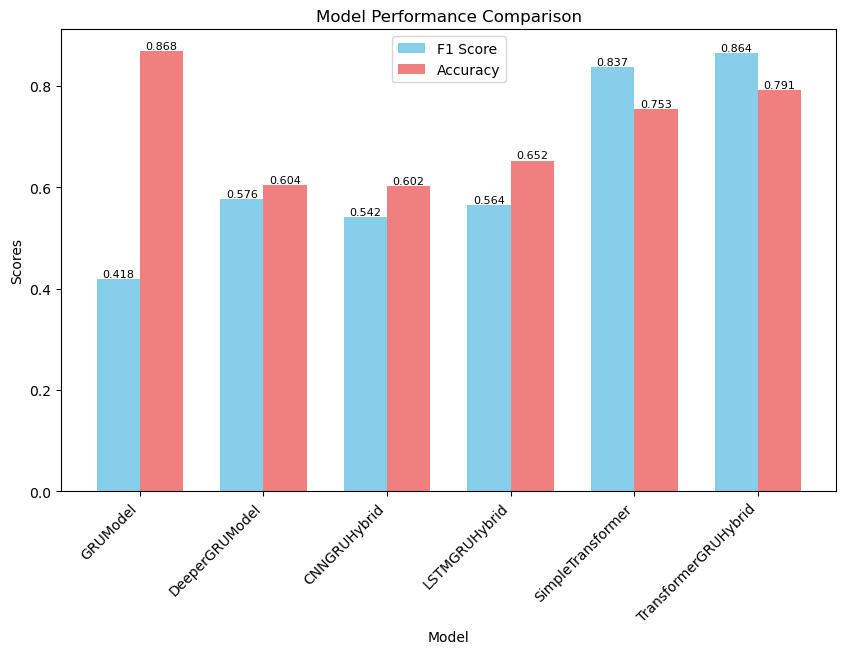

In [ ]:
models = ['GRUModel'] + [key for key in results.keys() if isinstance(results[key], dict)]
f1_scores = [results['best_f1']] + [results[key]['best_f1'] for key in results.keys() if isinstance(results[key], dict)]
accuracies = [results['best_accuracy']] + [results[key]['best_accuracy'] for key in results.keys() if isinstance(results[key], dict)]


x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, f1_scores, width, label='F1 Score', color='skyblue')
ax.bar(x + width/2, accuracies, width, label='Accuracy', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
for i, v in enumerate(f1_scores):
    ax.text(i - width/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
for i, v in enumerate(accuracies):
    ax.text(i + width/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)



plt.show()

# Section 5: Future Work

For future iterations, we have a few different ideas. ChatGPT has recommended data balancing techniques such as **SMOTE** or **undersampling** to address class imbalance more directly. Second, instead of a binary classifier, **cost-sensitive learning** or **focal loss** could help penalize false negatives more heavily. We could also try a different output layer function, like linear, to predict what the actual pwoer will be. These two models could walk hand-in-hand, and better help us characterize our system. Model-wise, experimenting with **bidirectional LSTMs**, **attention mechanisms**, or **CNN-LSTM hybrids** will help us, and the model, learn more nuanced temporal patterns. We want to mess around with the architecture quite a lot, and we have a schedule in place that will enable us to do so.

**Other Areas of Expansion:**

- Other Independent System Operator (ISO) Applications: ERCOT is just one of many ISOs in the United States. PJM (5-peaks), NYISO (1-peak), and ISO-NE (1-peak) all use coincident peak pricing. We could apply our model architecture to new data to see if weather variables impact other markets as much as they do Texan energy.

- Game Theory Extension: If large energy consumers all adopt similar 4CP forecasting models to avoid ERCOT fees, the collective reduction in demand may shift the actual peak to a different time—creating a coordination problem. This dynamic mirrors the Prisoner’s Dilemma, where individual rational behavior can lead to a suboptimal group outcome.




# Other Outside Sources and Thank Yous

- All places where ChatGPT and/or Grok were used in the notebook have been noted, alongside what they were used for!  We only used our own code in the proejct, and utilized ChatGPT/Grok for syntax fixes, which could be considered common knowledge under the first style reference in the Ed.  We figured it would be best practice to sill make mention of this.
- The only other link we referenced was https://www.amperon.co/blog/improved-coincident-peak-cp-alerts for info on other CP fees in different ISOs.
- We'd like to give a huge thank you to Professor Le Xie, who helped Trey come up with the idea for the project.
- Thank you to Alex Tonelli, our TF, for his insights!
- Thank you to the entire CS1090B course staff for your help across the whole semester. We had an awesome time in class, and we can't wait to take what we've learned with us into the post-graduation world.